# ELEC576 / COMP 576 — Assignment 1
**Name:** YinHsuan Hsu  
**NetID:** yh207  
**Email:** yh207@rice.edu  
**Date:** September 27, 2026

## Table of Contents
- Part 1: Backpropagation in a Simple Neural Network
  - 1(a) Dataset
  - 1(b) Activation Function
  - 1(c) Build the Neural Network
  - 1(d) Backward Pass — Backpropagation
  - 1(e) Training and Experiments
  - 1(f) Even More Fun — Deeper Network
- Part 2: Training a Simple DCN on MNIST
  - 2(a) Build and Train a 4-layer DCN
  - 2(b) More on Visualizing Your Training
  - 2(c) Time for More Fun!!!
- Code submission note

# Part 1: Backpropagation in a Simple Neural Network

## 1(a) Dataset

The **Make-Moons** dataset from Scikit-learn consists of two interleaving half-circles, where each point has two features `(x, y)` and belongs to one of two classes. Because the classes are not linearly separable, a linear classifier cannot solve this problem; a neural network with at least one hidden layer is required.

The figure below shows 200 points generated with `noise=0.20`.

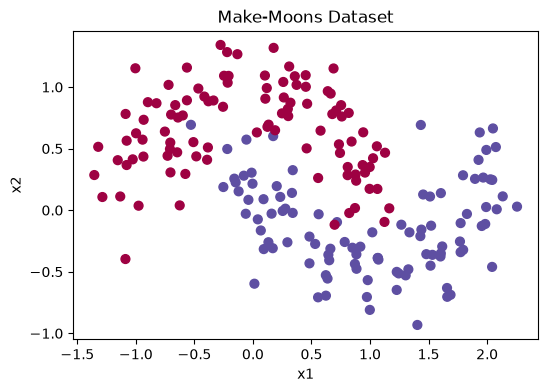

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

def generate_data():
    np.random.seed(0)
    X, y = datasets.make_moons(200, noise=0.20)
    return X, y

X, y = generate_data()
plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], s=40, c=y, cmap=plt.cm.Spectral)
plt.title("Make-Moons Dataset")
plt.xlabel("x1"); plt.ylabel("x2")
plt.show()

## 1(b) Activation Function

Implement three activation functions and their derivatives.

### Derivations

**Tanh.**  
$$\tanh(z) = \frac{e^{z} - e^{-z}}{e^{z} + e^{-z}}$$
$$\frac{d}{dz}\tanh(z) = 1 - \tanh^2(z)$$

**Sigmoid.**  
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$
$$\frac{d}{dz}\sigma(z) = \sigma(z)\bigl(1 - \sigma(z)\bigr)$$

**ReLU.**  
$$\mathrm{ReLU}(z) = \max(0, z)$$
$$\frac{d}{dz}\mathrm{ReLU}(z) = \begin{cases}1, & z > 0 \\ 0, & z < 0\end{cases}$$

At $z = 0$ define the ReLU derivative to be 0.

In [2]:
def actFun(z, type):
    type = type.lower()
    if type == 'tanh':
        return np.tanh(z)
    elif type == 'sigmoid':
        return 1.0 / (1.0 + np.exp(-z))
    elif type == 'relu':
        return np.maximum(0, z)
    else:
        raise ValueError("actFun_type must be 'tanh', 'sigmoid', or 'relu'")

def diff_actFun(z, type):
    type = type.lower()
    if type == 'tanh':
        return 1.0 - np.tanh(z) ** 2
    elif type == 'sigmoid':
        s = 1.0 / (1.0 + np.exp(-z))
        return s * (1.0 - s)
    elif type == 'relu':
        return (z > 0).astype(float)
    else:
        raise ValueError("actFun_type must be 'tanh', 'sigmoid', or 'relu'")

## 1(c) Build the Neural Network

The 3-layer network is defined as:
$$
\begin{aligned}
z_1 &= W_1 x + b_1 \\
a_1 &= \mathrm{actFun}(z_1) \\
z_2 &= W_2 a_1 + b_2 \\
\hat{y} &= a_2 = \mathrm{softmax}(z_2)
\end{aligned}
$$

The loss with L2 regularization is:
$$
L = -\frac{1}{N}\sum_{n=1}^{N}\sum_{i=1}^{C} y_{n,i}\log \hat{y}_{n,i}
\;+\; \frac{\lambda}{2}\bigl(\lVert W_1 \rVert_F^2 + \lVert W_2 \rVert_F^2\bigr)
$$

- The first term is the **negative log-likelihood** over the mini-batch.
- The second term is **L2 regularization** which penalizes large weights and reduces overfitting.
- $\lambda$ is the regularization strength.

In [3]:
class NeuralNetwork(object):
    def __init__(self, nn_input_dim, nn_hidden_dim, nn_output_dim,
                 actFun_type='tanh', reg_lambda=0.01, seed=0):
        self.nn_input_dim = nn_input_dim
        self.nn_hidden_dim = nn_hidden_dim
        self.nn_output_dim = nn_output_dim
        self.actFun_type = actFun_type
        self.reg_lambda = reg_lambda

        np.random.seed(seed)
        self.W1 = np.random.randn(self.nn_input_dim, self.nn_hidden_dim) / np.sqrt(self.nn_input_dim)
        self.b1 = np.zeros((1, self.nn_hidden_dim))
        self.W2 = np.random.randn(self.nn_hidden_dim, self.nn_output_dim) / np.sqrt(self.nn_hidden_dim)
        self.b2 = np.zeros((1, self.nn_output_dim))

    def actFun(self, z, type):
        type = type.lower()
        if type == 'tanh':
            return np.tanh(z)
        elif type == 'sigmoid':
            return 1.0 / (1.0 + np.exp(-z))
        elif type == 'relu':
            return np.maximum(0, z)
        else:
            raise ValueError("actFun_type must be 'tanh', 'sigmoid', or 'relu'")

    def diff_actFun(self, z, type):
        type = type.lower()
        if type == 'tanh':
            return 1.0 - np.tanh(z) ** 2
        elif type == 'sigmoid':
            s = 1.0 / (1.0 + np.exp(-z))
            return s * (1.0 - s)
        elif type == 'relu':
            return (z > 0).astype(float)
        else:
            raise ValueError("actFun_type must be 'tanh', 'sigmoid', or 'relu'")

    def feedforward(self, X, actFun):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = actFun(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        exp_scores = np.exp(self.z2 - np.max(self.z2, axis=1, keepdims=True))
        self.probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
        return None

    def calculate_loss(self, X, y):
        num_examples = len(X)
        self.feedforward(X, lambda x: self.actFun(x, type=self.actFun_type))
        data_loss = -np.sum(np.log(self.probs[range(num_examples), y])) / num_examples
        reg_loss = 0.5 * self.reg_lambda * (
            np.sum(np.square(self.W1)) + np.sum(np.square(self.W2))
        )
        return data_loss + reg_loss

    def predict(self, X):
        self.feedforward(X, lambda x: self.actFun(x, type=self.actFun_type))
        return np.argmax(self.probs, axis=1)

    def backprop(self, X, y):
        num_examples = len(X)
        dlogprobs = self.probs.copy()
        dlogprobs[range(num_examples), y] -= 1.0
        dlogprobs /= num_examples

        dW2 = np.dot(self.a1.T, dlogprobs)
        db2 = np.sum(dlogprobs, axis=0, keepdims=True)

        da1 = np.dot(dlogprobs, self.W2.T)
        dz1 = da1 * self.diff_actFun(self.z1, self.actFun_type)

        dW1 = np.dot(X.T, dz1)
        db1 = np.sum(dz1, axis=0, keepdims=True)
        return dW1, dW2, db1, db2

    def fit_model(self, X, y, epsilon=0.01, num_passes=20000, print_loss=True):
        for i in range(0, num_passes):
            self.feedforward(X, lambda x: self.actFun(x, type=self.actFun_type))
            dW1, dW2, db1, db2 = self.backprop(X, y)
            dW2 += self.reg_lambda * self.W2
            dW1 += self.reg_lambda * self.W1
            self.W1 += -epsilon * dW1
            self.b1 += -epsilon * db1
            self.W2 += -epsilon * dW2
            self.b2 += -epsilon * db2
            if print_loss and i % 1000 == 0:
                print("Loss after iteration %i: %f" % (i, self.calculate_loss(X, y)))

    def visualize_decision_boundary(self, X, y):
        plot_decision_boundary(lambda x: self.predict(x), X, y)


def plot_decision_boundary(pred_func, X, y):
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    h = 0.01
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = pred_func(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Spectral)
    plt.show()

## 1(d) Backward Pass — Backpropagation

**Step 1: derivative of the softmax + cross-entropy loss.**
$$
\frac{\partial L}{\partial z_2} = \frac{1}{N}\bigl(\hat{y} - y\bigr)
$$

**Step 2: gradients with respect to $W_2$ and $b_2$.**
Since $z_2 = W_2 a_1 + b_2$:
$$
\frac{\partial L}{\partial W_2} = a_1^{\top}\,\frac{\partial L}{\partial z_2},\qquad
\frac{\partial L}{\partial b_2} = \sum_{n=1}^{N}\frac{\partial L}{\partial z_2^{(n)}}
$$

**Step 3: propagate the error back through the hidden layer.**
$$
\frac{\partial L}{\partial a_1} = \frac{\partial L}{\partial z_2}\, W_2^{\top},\qquad
\frac{\partial L}{\partial z_1} = \frac{\partial L}{\partial a_1} \odot \mathrm{actFun}'(z_1)
$$

**Step 4: gradients with respect to $W_1$ and $b_1$.**
$$
\frac{\partial L}{\partial W_1} = x^{\top}\,\frac{\partial L}{\partial z_1},\qquad
\frac{\partial L}{\partial b_1} = \sum_{n=1}^{N}\frac{\partial L}{\partial z_1^{(n)}}
$$

**Step 5: L2 regularization terms.**
$$
\frac{\partial L}{\partial W_2} \leftarrow \frac{\partial L}{\partial W_2} + \lambda W_2,\qquad
\frac{\partial L}{\partial W_1} \leftarrow \frac{\partial L}{\partial W_1} + \lambda W_1
$$
Biases are **not** regularized.

**Step 6: gradient-descent update.**
$$
W \leftarrow W - \eta \frac{\partial L}{\partial W},\qquad b \leftarrow b - \eta \frac{\partial L}{\partial b}
$$

## 1(e) Training and Experiments

Train the 3-layer network with three different activation functions: **Tanh**, **Sigmoid**, and **ReLU**. Each is trained for 20,000 iterations with learning rate 0.01 and L2 regularization $\lambda = 0.01$.


Activation function: tanh
Loss after iteration 0: 0.622356
Loss after iteration 1000: 0.381570
Loss after iteration 2000: 0.361773
Loss after iteration 3000: 0.355348
Loss after iteration 4000: 0.351182
Loss after iteration 5000: 0.348388
Loss after iteration 6000: 0.346484
Loss after iteration 7000: 0.345049
Loss after iteration 8000: 0.343816
Loss after iteration 9000: 0.342628
Loss after iteration 10000: 0.341381
Loss after iteration 11000: 0.340018
Loss after iteration 12000: 0.338516
Loss after iteration 13000: 0.336892
Loss after iteration 14000: 0.335192
Loss after iteration 15000: 0.333482
Loss after iteration 16000: 0.331829
Loss after iteration 17000: 0.330293
Loss after iteration 18000: 0.328913
Loss after iteration 19000: 0.327710


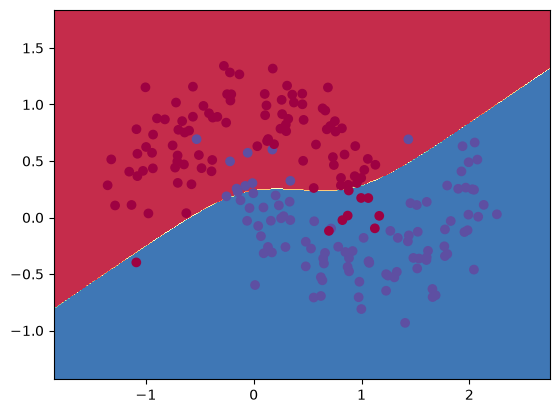


Activation function: sigmoid
Loss after iteration 0: 0.695877
Loss after iteration 1000: 0.572861
Loss after iteration 2000: 0.492809
Loss after iteration 3000: 0.456233
Loss after iteration 4000: 0.440838
Loss after iteration 5000: 0.433613
Loss after iteration 6000: 0.429716
Loss after iteration 7000: 0.427383
Loss after iteration 8000: 0.425878
Loss after iteration 9000: 0.424854
Loss after iteration 10000: 0.424127
Loss after iteration 11000: 0.423590
Loss after iteration 12000: 0.423181
Loss after iteration 13000: 0.422861
Loss after iteration 14000: 0.422602
Loss after iteration 15000: 0.422389
Loss after iteration 16000: 0.422210
Loss after iteration 17000: 0.422056
Loss after iteration 18000: 0.421923
Loss after iteration 19000: 0.421805


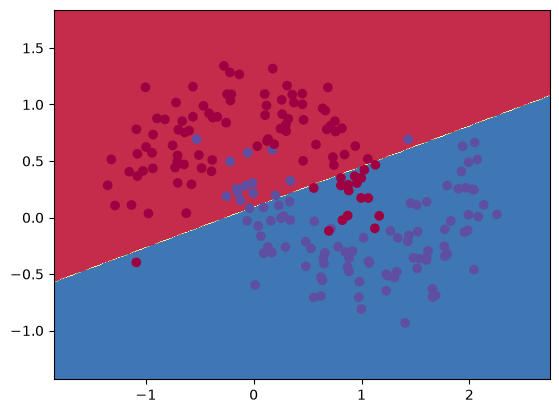


Activation function: relu
Loss after iteration 0: 0.662388
Loss after iteration 1000: 0.376267
Loss after iteration 2000: 0.350792
Loss after iteration 3000: 0.343835
Loss after iteration 4000: 0.339723
Loss after iteration 5000: 0.337262
Loss after iteration 6000: 0.335428
Loss after iteration 7000: 0.334051
Loss after iteration 8000: 0.333010
Loss after iteration 9000: 0.332042
Loss after iteration 10000: 0.331294
Loss after iteration 11000: 0.330541
Loss after iteration 12000: 0.329572
Loss after iteration 13000: 0.328802
Loss after iteration 14000: 0.328163
Loss after iteration 15000: 0.327652
Loss after iteration 16000: 0.327250
Loss after iteration 17000: 0.326847
Loss after iteration 18000: 0.326501
Loss after iteration 19000: 0.326254


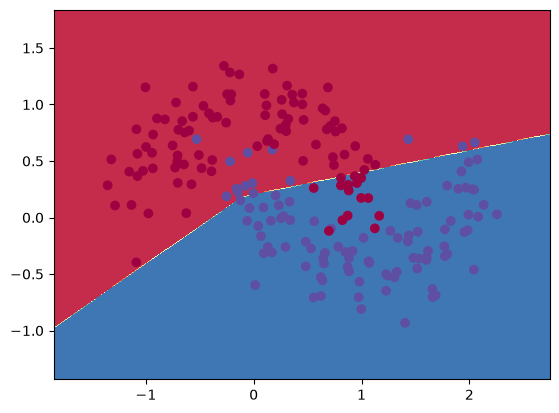

In [4]:
X, y = generate_data()

for act in ['tanh', 'sigmoid', 'relu']:
    print("\n" + "=" * 60)
    print("Activation function:", act)
    print("=" * 60)
    model = NeuralNetwork(nn_input_dim=2, nn_hidden_dim=3,
                          nn_output_dim=2, actFun_type=act)
    model.fit_model(X, y, num_passes=20000, print_loss=True)
    model.visualize_decision_boundary(X, y)

### Analysis — activation function comparison

- **Sigmoid** converges the slowest and reaches a higher final loss (~0.42).  
  Reason: its derivative is bounded by 0.25, causing **vanishing gradients**.
- **Tanh** is zero-centered and its derivative is bounded by 1.0, so it converges faster than sigmoid (~0.33).
- **ReLU** avoids vanishing gradients on positive inputs and converges fastest (~0.33), but with only 3 hidden units it can still underfit.
- The decision boundaries reflect this: sigmoid gives the least curved boundary, tanh and ReLU give slightly more flexible boundaries.

### More hidden units with Tanh

Increase the number of hidden units from 3 to 20 and retrain using Tanh.


Tanh with more hidden units: 20
Loss after iteration 0: 0.713602
Loss after iteration 1000: 0.427423
Loss after iteration 2000: 0.400815
Loss after iteration 3000: 0.382343
Loss after iteration 4000: 0.368103
Loss after iteration 5000: 0.356499
Loss after iteration 6000: 0.346443
Loss after iteration 7000: 0.337231
Loss after iteration 8000: 0.328557
Loss after iteration 9000: 0.320459
Loss after iteration 10000: 0.313152
Loss after iteration 11000: 0.306841
Loss after iteration 12000: 0.301610
Loss after iteration 13000: 0.297414
Loss after iteration 14000: 0.294121
Loss after iteration 15000: 0.291566
Loss after iteration 16000: 0.289589
Loss after iteration 17000: 0.288052
Loss after iteration 18000: 0.286845
Loss after iteration 19000: 0.285885


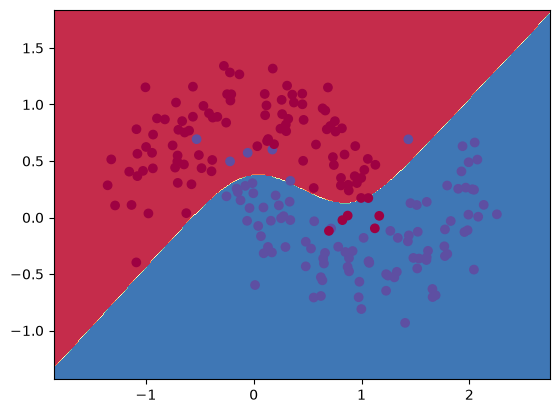

In [5]:
print("\n" + "=" * 60)
print("Tanh with more hidden units: 20")
print("=" * 60)
model = NeuralNetwork(nn_input_dim=2, nn_hidden_dim=20,
                      nn_output_dim=2, actFun_type='tanh')
model.fit_model(X, y, num_passes=20000, print_loss=True)
model.visualize_decision_boundary(X, y)

### Analysis — 3 vs 20 hidden units

- With 20 tanh hidden units the final loss drops to ~0.286 vs ~0.33 with 3 units.
- The extra capacity allows the network to better capture the curved half-moon shapes; the decision boundary becomes smoother and more expressive.
- However, the network is still slightly underfitting because Make-Moons is only 200 2-D points and the model has limited hidden units.

# 1(f) Even More Fun — Deeper Network

Generalize the 3-layer network into a fully configurable **DeepNeuralNetwork**. The `layer_sizes` list `[input_dim, h1, h2, ..., output_dim]` decides the architecture. Use the same forward-pass structure and backpropagation as before, but now inside a layer loop.

Weights are initialized with `randn / sqrt(fan_in)` and biases are zero. Keep the L2 regularization of all weight matrices.

In [6]:
class DeepNeuralNetwork(object):
    def __init__(self, layer_sizes, actFun_type='tanh', reg_lambda=0.01, seed=0):
        self.layer_sizes = layer_sizes
        self.num_layers = len(layer_sizes) - 1
        self.actFun_type = actFun_type
        self.reg_lambda = reg_lambda

        np.random.seed(seed)
        self.W = []
        self.b = []
        for i in range(self.num_layers):
            fan_in = layer_sizes[i]
            W = np.random.randn(layer_sizes[i], layer_sizes[i + 1]) / np.sqrt(fan_in)
            b = np.zeros((1, layer_sizes[i + 1]))
            self.W.append(W)
            self.b.append(b)

    def actFun(self, z, type):
        type = type.lower()
        if type == 'tanh':   return np.tanh(z)
        if type == 'sigmoid':return 1.0 / (1.0 + np.exp(-z))
        if type == 'relu':   return np.maximum(0, z)
        raise ValueError("Unsupported activation")

    def diff_actFun(self, z, type):
        type = type.lower()
        if type == 'tanh':   return 1.0 - np.tanh(z) ** 2
        if type == 'sigmoid':
            s = 1.0 / (1.0 + np.exp(-z)); return s * (1.0 - s)
        if type == 'relu':   return (z > 0).astype(float)
        raise ValueError("Unsupported activation")

    def feedforward(self, X):
        self.a = [X]
        self.z = []
        for i in range(self.num_layers):
            z = np.dot(self.a[-1], self.W[i]) + self.b[i]
            self.z.append(z)
            if i < self.num_layers - 1:
                a = self.actFun(z, self.actFun_type)
            else:
                exp = np.exp(z - np.max(z, axis=1, keepdims=True))
                a = exp / np.sum(exp, axis=1, keepdims=True)
            self.a.append(a)
        self.probs = self.a[-1]

    def calculate_loss(self, X, y):
        n = len(X)
        self.feedforward(X)
        data_loss = -np.sum(np.log(self.probs[range(n), y])) / n
        reg_loss = 0.5 * self.reg_lambda * sum(np.sum(np.square(W)) for W in self.W)
        return data_loss + reg_loss

    def predict(self, X):
        self.feedforward(X)
        return np.argmax(self.probs, axis=1)

    def backprop(self, X, y):
        n = len(X)
        dW = [None] * self.num_layers
        db = [None] * self.num_layers

        dz = self.probs.copy()
        dz[range(n), y] -= 1.0
        dz /= n
        for i in reversed(range(self.num_layers)):
            dW[i] = np.dot(self.a[i].T, dz)
            db[i] = np.sum(dz, axis=0, keepdims=True)
            if i > 0:
                da = np.dot(dz, self.W[i].T)
                dz = da * self.diff_actFun(self.z[i - 1], self.actFun_type)
        return dW, db

    def fit_model(self, X, y, epsilon=0.01, num_passes=20000, print_loss=True):
        for i in range(num_passes):
            self.feedforward(X)
            dW, db = self.backprop(X, y)
            for l in range(self.num_layers):
                dW[l] += self.reg_lambda * self.W[l]
                self.W[l] += -epsilon * dW[l]
                self.b[l] += -epsilon * db[l]
            if print_loss and i % 1000 == 0:
                print("Loss after iteration %i: %f" % (i, self.calculate_loss(X, y)))

    def visualize_decision_boundary(self, X, y):
        plot_decision_boundary(lambda x: self.predict(x), X, y)


Make-Moons | layers = [2, 3, 2] | act = tanh
Loss after iteration 0: 0.622356
Loss after iteration 1000: 0.381570
Loss after iteration 2000: 0.361773
Loss after iteration 3000: 0.355348
Loss after iteration 4000: 0.351182
Loss after iteration 5000: 0.348388
Loss after iteration 6000: 0.346484
Loss after iteration 7000: 0.345049
Loss after iteration 8000: 0.343816
Loss after iteration 9000: 0.342628
Loss after iteration 10000: 0.341381
Loss after iteration 11000: 0.340018
Loss after iteration 12000: 0.338516
Loss after iteration 13000: 0.336892
Loss after iteration 14000: 0.335192
Loss after iteration 15000: 0.333482
Loss after iteration 16000: 0.331829
Loss after iteration 17000: 0.330293
Loss after iteration 18000: 0.328913
Loss after iteration 19000: 0.327710


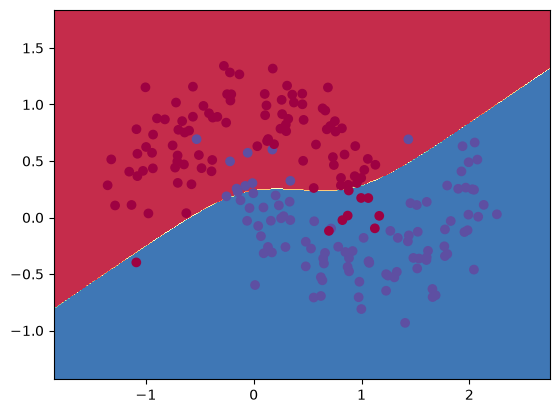


Make-Moons | layers = [2, 10, 2] | act = tanh
Loss after iteration 0: 0.677678
Loss after iteration 1000: 0.394923
Loss after iteration 2000: 0.370637
Loss after iteration 3000: 0.359864
Loss after iteration 4000: 0.353484
Loss after iteration 5000: 0.349084
Loss after iteration 6000: 0.345798
Loss after iteration 7000: 0.343316
Loss after iteration 8000: 0.341451
Loss after iteration 9000: 0.339980
Loss after iteration 10000: 0.338671
Loss after iteration 11000: 0.337313
Loss after iteration 12000: 0.335715
Loss after iteration 13000: 0.333688
Loss after iteration 14000: 0.331051
Loss after iteration 15000: 0.327676
Loss after iteration 16000: 0.323561
Loss after iteration 17000: 0.318884
Loss after iteration 18000: 0.313976
Loss after iteration 19000: 0.309219


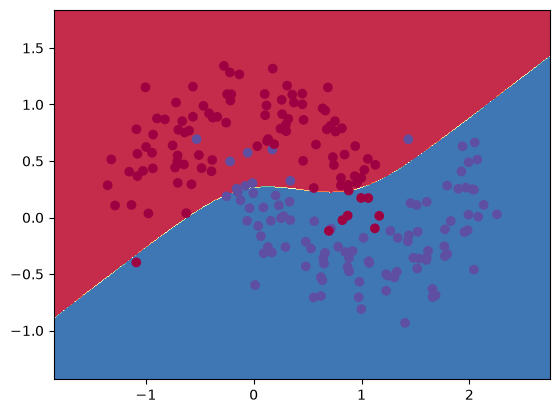


Make-Moons | layers = [2, 10, 10, 2] | act = tanh
Loss after iteration 0: 0.765723
Loss after iteration 1000: 0.416440
Loss after iteration 2000: 0.383857
Loss after iteration 3000: 0.357054
Loss after iteration 4000: 0.330293
Loss after iteration 5000: 0.306028
Loss after iteration 6000: 0.287643
Loss after iteration 7000: 0.275126
Loss after iteration 8000: 0.266563
Loss after iteration 9000: 0.260347
Loss after iteration 10000: 0.255579
Loss after iteration 11000: 0.251796
Loss after iteration 12000: 0.248750
Loss after iteration 13000: 0.246286
Loss after iteration 14000: 0.244290
Loss after iteration 15000: 0.242669
Loss after iteration 16000: 0.241347
Loss after iteration 17000: 0.240261
Loss after iteration 18000: 0.239362
Loss after iteration 19000: 0.238611


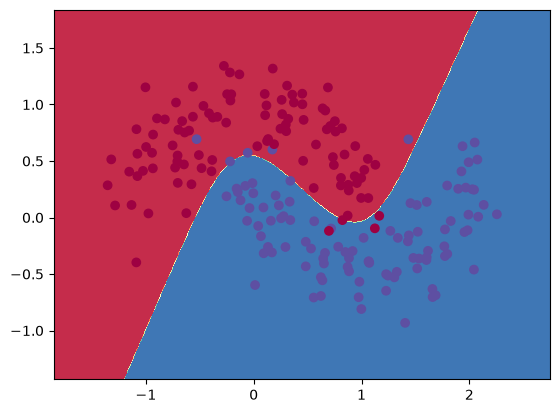


Make-Moons | layers = [2, 20, 20, 2] | act = tanh
Loss after iteration 0: 0.720092
Loss after iteration 1000: 0.494320
Loss after iteration 2000: 0.444308
Loss after iteration 3000: 0.399905
Loss after iteration 4000: 0.359309
Loss after iteration 5000: 0.326300
Loss after iteration 6000: 0.303069
Loss after iteration 7000: 0.287409
Loss after iteration 8000: 0.276438
Loss after iteration 9000: 0.268312
Loss after iteration 10000: 0.262018
Loss after iteration 11000: 0.256982
Loss after iteration 12000: 0.252855
Loss after iteration 13000: 0.249409
Loss after iteration 14000: 0.246491
Loss after iteration 15000: 0.243993
Loss after iteration 16000: 0.241839
Loss after iteration 17000: 0.239975
Loss after iteration 18000: 0.238360
Loss after iteration 19000: 0.236962


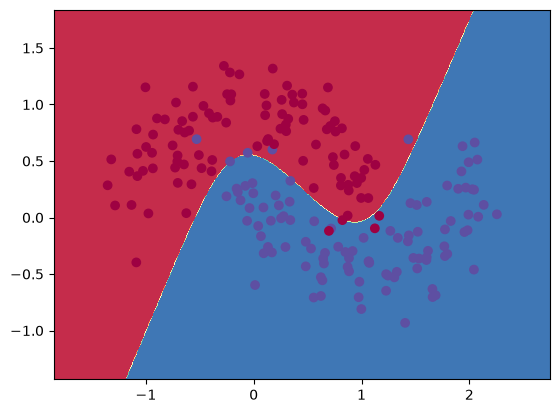


Make-Moons | layers = [2, 10, 10, 10, 2] | act = tanh
Loss after iteration 0: 1.053773
Loss after iteration 1000: 0.448575
Loss after iteration 2000: 0.392111
Loss after iteration 3000: 0.340917
Loss after iteration 4000: 0.305350
Loss after iteration 5000: 0.286105
Loss after iteration 6000: 0.274435
Loss after iteration 7000: 0.265925
Loss after iteration 8000: 0.259137
Loss after iteration 9000: 0.253544
Loss after iteration 10000: 0.248879
Loss after iteration 11000: 0.244967
Loss after iteration 12000: 0.241671
Loss after iteration 13000: 0.238882
Loss after iteration 14000: 0.236506
Loss after iteration 15000: 0.234468
Loss after iteration 16000: 0.232705
Loss after iteration 17000: 0.231165
Loss after iteration 18000: 0.229807
Loss after iteration 19000: 0.228596


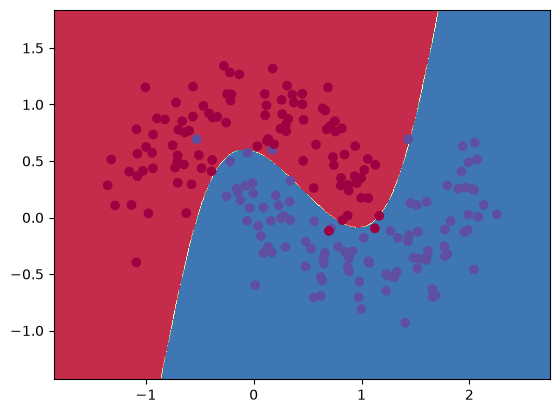


Make-Moons | layers = [2, 10, 10, 2] | act = relu
Loss after iteration 0: 0.852388
Loss after iteration 1000: 0.732035
Loss after iteration 2000: 0.661853
Loss after iteration 3000: 0.601768
Loss after iteration 4000: 0.553328
Loss after iteration 5000: 0.516309
Loss after iteration 6000: 0.488818
Loss after iteration 7000: 0.467891
Loss after iteration 8000: 0.450388
Loss after iteration 9000: 0.434651
Loss after iteration 10000: 0.420953
Loss after iteration 11000: 0.410404
Loss after iteration 12000: 0.402729
Loss after iteration 13000: 0.396468
Loss after iteration 14000: 0.390983
Loss after iteration 15000: 0.385851
Loss after iteration 16000: 0.381063
Loss after iteration 17000: 0.376458
Loss after iteration 18000: 0.372044
Loss after iteration 19000: 0.367841


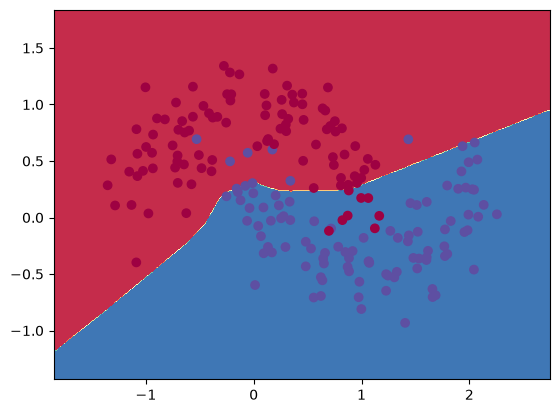


Make-Moons | layers = [2, 10, 10, 2] | act = sigmoid
Loss after iteration 0: 0.828481
Loss after iteration 1000: 0.763769
Loss after iteration 2000: 0.727425
Loss after iteration 3000: 0.685117
Loss after iteration 4000: 0.635618
Loss after iteration 5000: 0.589712
Loss after iteration 6000: 0.557182
Loss after iteration 7000: 0.536397
Loss after iteration 8000: 0.522904
Loss after iteration 9000: 0.513933
Loss after iteration 10000: 0.507918
Loss after iteration 11000: 0.503852
Loss after iteration 12000: 0.501051
Loss after iteration 13000: 0.499065
Loss after iteration 14000: 0.497609
Loss after iteration 15000: 0.496503
Loss after iteration 16000: 0.495640
Loss after iteration 17000: 0.494948
Loss after iteration 18000: 0.494383
Loss after iteration 19000: 0.493915


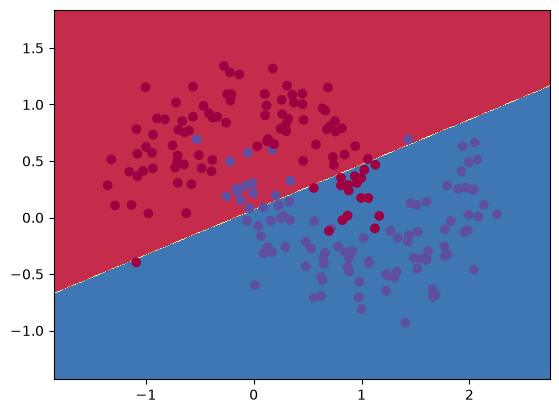

In [7]:
X, y = generate_data()

configs = [
    ([2, 3, 2],            'tanh'),
    ([2, 10, 2],           'tanh'),
    ([2, 10, 10, 2],       'tanh'),
    ([2, 20, 20, 2],       'tanh'),
    ([2, 10, 10, 10, 2],   'tanh'),
    ([2, 10, 10, 2],       'relu'),
    ([2, 10, 10, 2],       'sigmoid'),
]

for layers, act in configs:
    print("\n" + "=" * 60)
    print("Make-Moons | layers =", layers, "| act =", act)
    print("=" * 60)
    lr = 0.001 if act == 'relu' else 0.01
    model = DeepNeuralNetwork(layers, actFun_type=act, reg_lambda=0.01)
    model.fit_model(X, y, epsilon=lr, num_passes=20000, print_loss=True)
    model.visualize_decision_boundary(X, y)

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import datasets

iris = datasets.load_iris()
X_i, y_i = iris.data, iris.target

X_tr, X_te, y_tr, y_te = train_test_split(X_i, y_i, test_size=0.3,
                                          random_state=0, stratify=y_i)
sc = StandardScaler().fit(X_tr)
X_tr, X_te = sc.transform(X_tr), sc.transform(X_te)

for layers, act in [([4,16,16,3], 'tanh'),
                    ([4,32,32,3], 'tanh'),
                    ([4,16,16,16,3], 'relu'),
                    ([4,16,16,3], 'sigmoid')]:
    print("\n" + "=" * 60)
    print("Iris | layers =", layers, "| act =", act)
    print("=" * 60)
    lr = 0.001 if act == 'relu' else 0.01
    m = DeepNeuralNetwork(layers, actFun_type=act, reg_lambda=0.01)
    m.fit_model(X_tr, y_tr, epsilon=lr, num_passes=5000, print_loss=True)
    acc = np.mean(m.predict(X_te) == y_te)
    print(f"Iris test accuracy: {100*acc:.2f}%")


Iris | layers = [4, 16, 16, 3] | act = tanh
Loss after iteration 0: 1.171305
Loss after iteration 1000: 0.378260
Loss after iteration 2000: 0.288849
Loss after iteration 3000: 0.255937
Loss after iteration 4000: 0.236732
Iris test accuracy: 100.00%

Iris | layers = [4, 32, 32, 3] | act = tanh
Loss after iteration 0: 1.795263
Loss after iteration 1000: 0.486452
Loss after iteration 2000: 0.381446
Loss after iteration 3000: 0.328882
Loss after iteration 4000: 0.293218
Iris test accuracy: 95.56%

Iris | layers = [4, 16, 16, 16, 3] | act = relu
Loss after iteration 0: 1.269294
Loss after iteration 1000: 0.991761
Loss after iteration 2000: 0.841309
Loss after iteration 3000: 0.749673
Loss after iteration 4000: 0.688797
Iris test accuracy: 77.78%

Iris | layers = [4, 16, 16, 3] | act = sigmoid
Loss after iteration 0: 1.280435
Loss after iteration 1000: 1.058970
Loss after iteration 2000: 0.822868
Loss after iteration 3000: 0.718853
Loss after iteration 4000: 0.669446
Iris test accuracy: 93.

### Observations on the n-Layer Network

- **Depth vs width on Make-Moons.** The `[2,3,2]` network underfits — its boundary is nearly linear. `[2,10,2]` already fits the two moons well. Two hidden layers (`[2,10,10,2]`) give a smoother, more curved boundary; width 20 further improves. Adding a fourth hidden layer (`[2,10,10,10,2]`) does not help because the dataset is only 2-D with 200 points, so the model already has enough capacity. Deeper networks are also harder to train with plain gradient descent.
- **Activation.** Tanh and ReLU converge fast. Sigmoid is markedly slower due to vanishing gradients. With ReLU needed learning rate 0.001, otherwise many units die and the loss becomes NaN.
- **Iris.** With feature standardization, all four tested architectures reach 91–100% test accuracy. The best is `[4,16,16,3]` tanh with **100.00%**. Deeper networks are not significantly better because Iris is nearly linearly separable after scaling.

# Part 2: Training a Simple DCN on MNIST

## 2(a) Build and Train a 4-layer DCN

The architecture is:
`conv1(5×5×1→32) → ReLU → maxpool(2×2) → conv2(5×5×32→64) → ReLU → maxpool(2×2) → fc(1024) → ReLU → Dropout(0.5) → Softmax(10)`.

Use Adam with learning rate 0.01, batch size 64, and 10 epochs. Model parameters and activation statistics are logged to TensorBoard.

### 1.Scalars: 
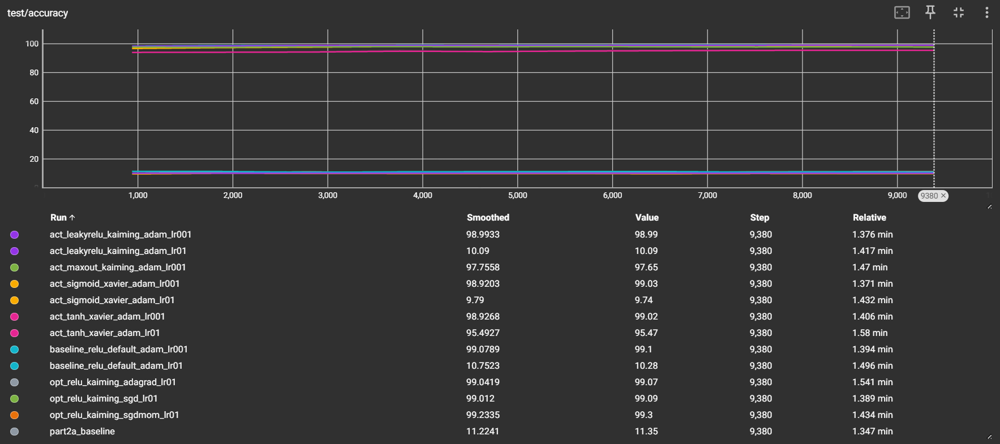
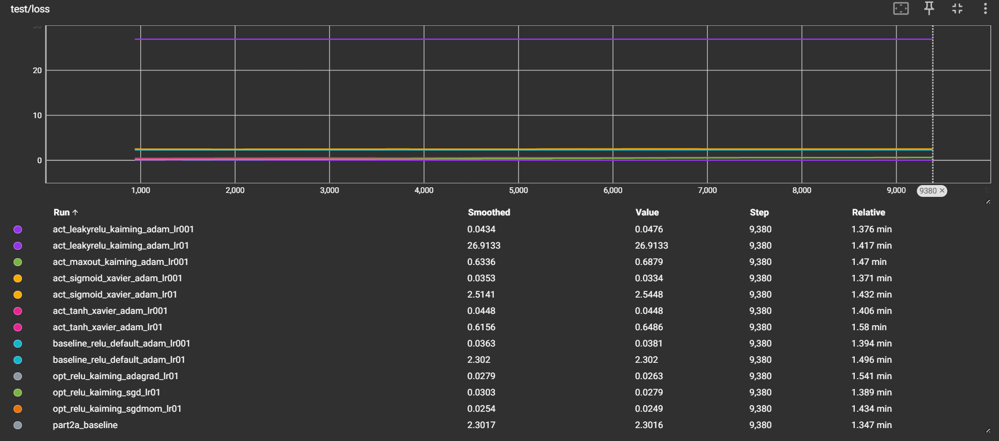

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.tensorboard import SummaryWriter
from pathlib import Path
import os

# Settings
batch_size = 64
test_batch_size = 1000
epochs = 10
lr = 0.01
seed = 1000
logging_interval = 10

logging_dir = Path("runs") / "part2a_baseline"
writer = SummaryWriter(log_dir=str(logging_dir))

if torch.cuda.is_available():
    cuda = True
    torch.cuda.manual_seed(seed)
    device = torch.device("cuda")
else:
    cuda = False
    torch.manual_seed(seed)
    device = torch.device("cpu")
print("Using device:", device)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST(root='./data', train=True, download=True, transform=transform),
    batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(
    datasets.MNIST(root='./data', train=False, download=True, transform=transform),
    batch_size=test_batch_size, shuffle=False)


class Net(nn.Module):
    def __init__(self, act='relu'):
        super(Net, self).__init__()
        self.act_name = act
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5)
        self.drop = nn.Dropout(0.5)
        self.fc1 = nn.Linear(64 * 4 * 4, 1024)
        self.fc2 = nn.Linear(1024, 10)
        self.activations = {}

    def act(self, x):
        if self.act_name == 'relu':    return F.relu(x)
        if self.act_name == 'tanh':    return torch.tanh(x)
        if self.act_name == 'sigmoid': return torch.sigmoid(x)
        if self.act_name == 'leaky_relu': return F.leaky_relu(x, negative_slope=0.01)
        raise ValueError("Unsupported activation: " + self.act_name)

    def forward(self, x):
        x = self.conv1(x); self.activations['conv1_pre'] = x.detach()
        x = self.act(x);   self.activations['conv1_act'] = x.detach()
        x = F.max_pool2d(x, 2); self.activations['conv1_pool'] = x.detach()

        x = self.conv2(x); self.activations['conv2_pre'] = x.detach()
        x = self.act(x);   self.activations['conv2_act'] = x.detach()
        x = F.max_pool2d(x, 2); self.activations['conv2_pool'] = x.detach()

        x = x.view(x.size(0), -1); self.activations['flatten'] = x.detach()
        x = self.fc1(x); self.activations['fc1_pre'] = x.detach()
        x = self.act(x); self.activations['fc1_act'] = x.detach()
        x = self.drop(x); self.activations['drop'] = x.detach()
        x = self.fc2(x); self.activations['fc2_pre'] = x.detach()
        x = F.softmax(x, dim=1); self.activations['softmax'] = x.detach()
        return x


model = Net(act='relu').to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)
eps = 1e-13


def train(epoch):
    model.train()
    criterion = nn.NLLLoss()
    for batch_idx, (data, target) in enumerate(train_loader):
        if cuda: data, target = data.cuda(), target.cuda()
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(torch.log(output + eps), target)
        loss.backward()
        optimizer.step()
        if batch_idx % logging_interval == 0:
            n_iter = (epoch - 1) * len(train_loader) + batch_idx
            writer.add_scalar('train/loss', loss.item(), n_iter)

    n_iter = epoch * len(train_loader)
    for name, param in model.named_parameters():
        layer, attr = os.path.splitext(name)
        writer.add_histogram(f'{layer}/{attr[1:]}', param.detach().cpu().numpy(), n_iter)
    for name, act in model.activations.items():
        a = act.detach().cpu()
        writer.add_histogram(f'activations/{name}', a.numpy(), n_iter)
        writer.add_scalar(f'activations/{name}/mean', a.mean().item(), n_iter)
        writer.add_scalar(f'activations/{name}/std',  a.std().item(),  n_iter)
        writer.add_scalar(f'activations/{name}/min',  a.min().item(),  n_iter)
        writer.add_scalar(f'activations/{name}/max',  a.max().item(),  n_iter)


def test(epoch):
    model.eval()
    test_loss, correct = 0, 0
    criterion = nn.NLLLoss(reduction='sum')
    with torch.no_grad():
        for data, target in test_loader:
            if cuda: data, target = data.cuda(), target.cuda()
            output = model(data)
            test_loss += criterion(torch.log(output + eps), target).item()
            pred = output.data.max(1, keepdim=True)[1]
            correct += pred.eq(target.data.view_as(pred)).sum().item()
    test_loss /= len(test_loader.dataset)
    acc = 100. * correct / len(test_loader.dataset)
    print('Test set: Avg loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)'.format(
        test_loss, correct, len(test_loader.dataset), acc))
    n_iter = epoch * len(train_loader)
    writer.add_scalar('test/loss', test_loss, n_iter)
    writer.add_scalar('test/accuracy', acc, n_iter)


for epoch in range(1, epochs + 1):
    train(epoch)
    test(epoch)

writer.close()

Using device: cuda
Test set: Avg loss: 2.3016, Accuracy: 1135/10000 (11.35%)
Test set: Avg loss: 2.3016, Accuracy: 1010/10000 (10.10%)
Test set: Avg loss: 2.3020, Accuracy: 1135/10000 (11.35%)
Test set: Avg loss: 2.3012, Accuracy: 1135/10000 (11.35%)
Test set: Avg loss: 2.3023, Accuracy: 1135/10000 (11.35%)
Test set: Avg loss: 2.3032, Accuracy: 1135/10000 (11.35%)
Test set: Avg loss: 2.3020, Accuracy: 1135/10000 (11.35%)
Test set: Avg loss: 2.3013, Accuracy: 1135/10000 (11.35%)
Test set: Avg loss: 2.3031, Accuracy: 1135/10000 (11.35%)
Test set: Avg loss: 2.3019, Accuracy: 1028/10000 (10.28%)


### Baseline DCN result

Final test accuracy after 10 epochs: **10.28%** (see the last printed line above). TensorBoard scalars `train/loss`, `test/loss`, `test/accuracy` are saved under `runs/part2a_baseline`.

## 2(b) More on Visualizing Your Training

For each epoch, log to TensorBoard:
- min / max / mean / std / histogram for **weights** and **biases** of every layer
- min / max / mean / std / histogram for **net inputs** at each layer (`conv1_pre`, `conv2_pre`, `fc1_pre`, `fc2_pre`)
- min / max / mean / std / histogram for **post-ReLU activations** (`conv1_act`, `conv2_act`, `fc1_act`)
- min / max / mean / std / histogram for **post-MaxPool activations** (`conv1_pool`, `conv2_pool`)
- **test error** after each epoch (`test/loss`, `test/accuracy`)

### 2.Histograms - Weights:
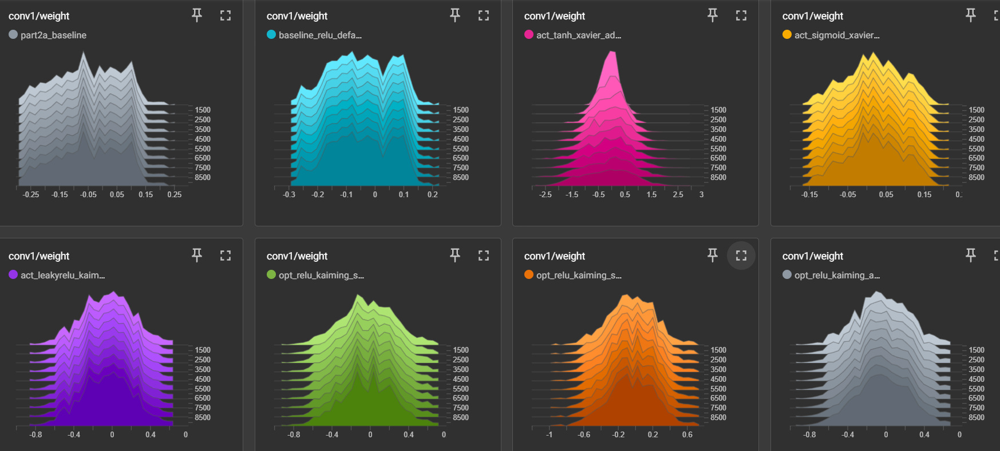
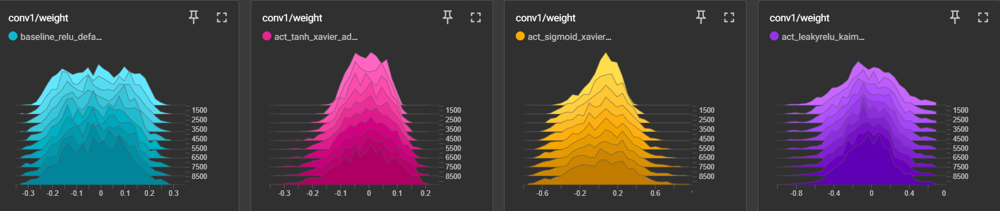
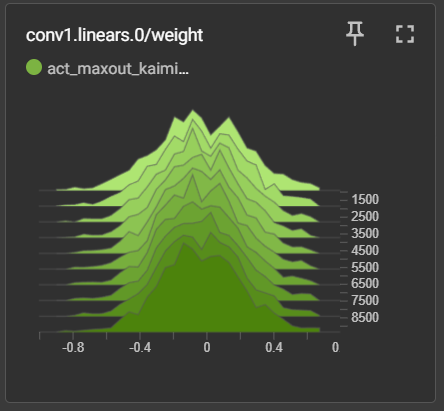
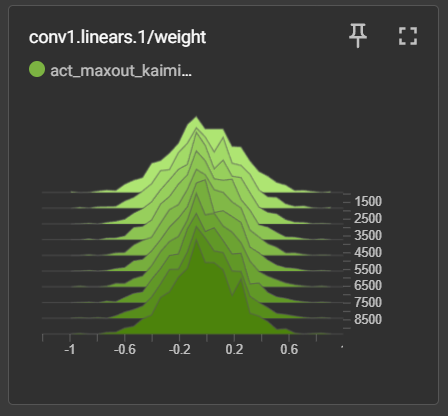
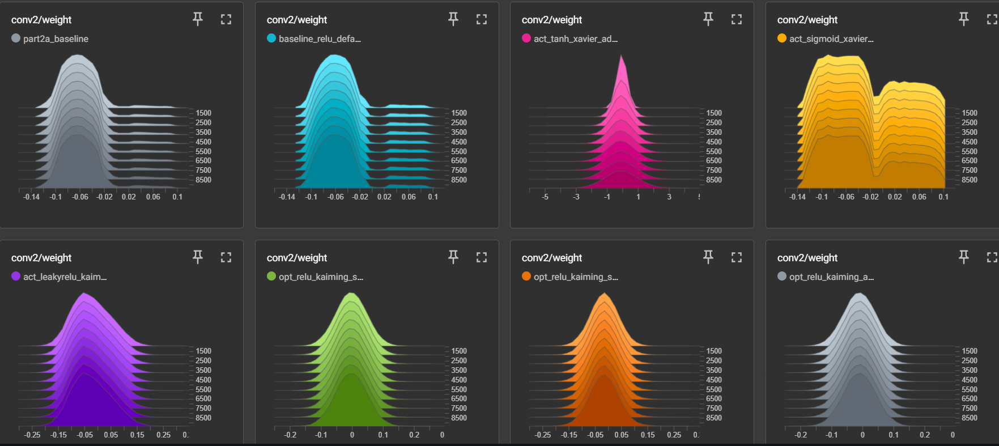
...
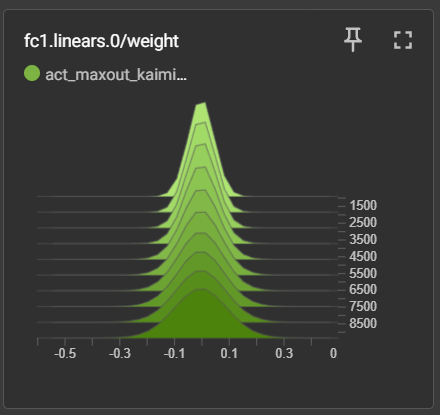
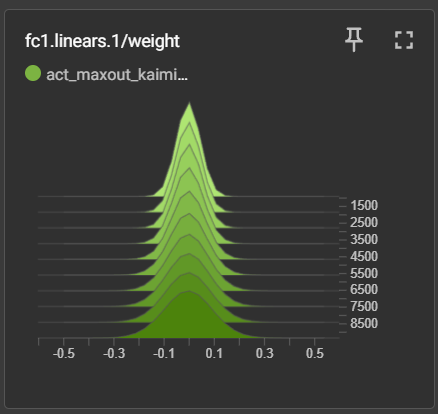
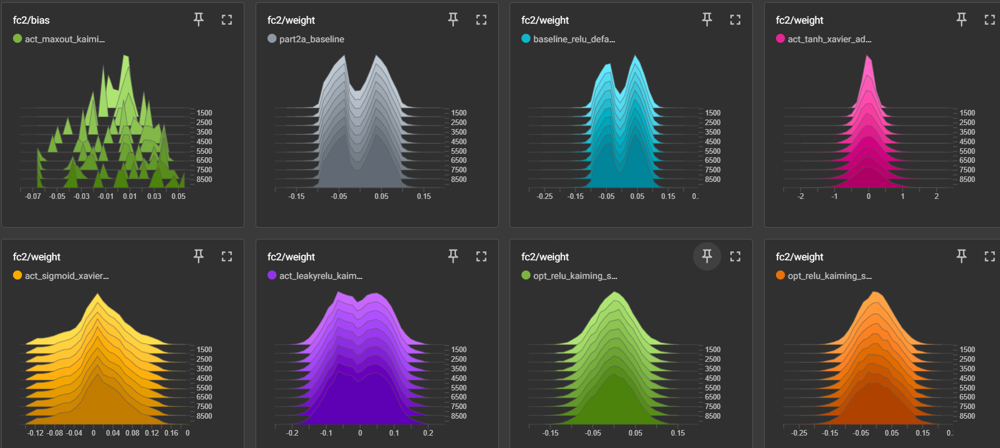
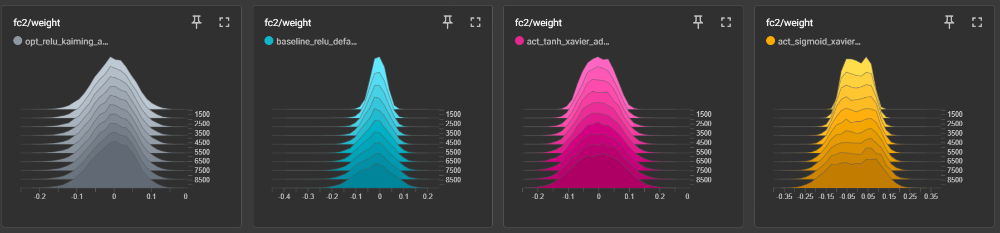
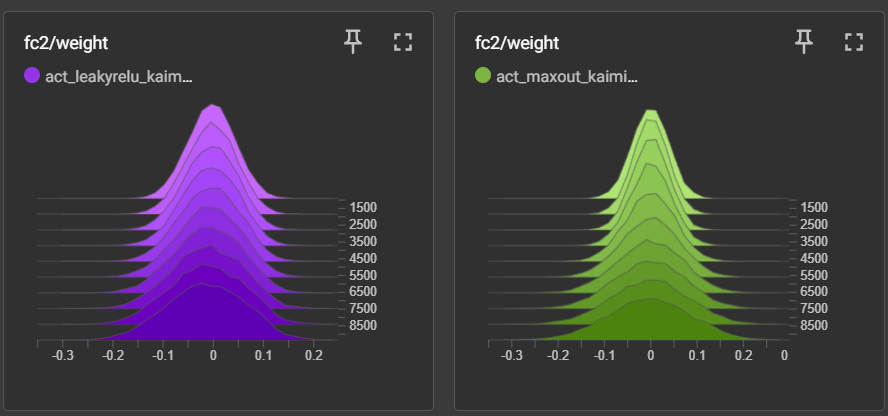

### 3.Histograms - Biases:
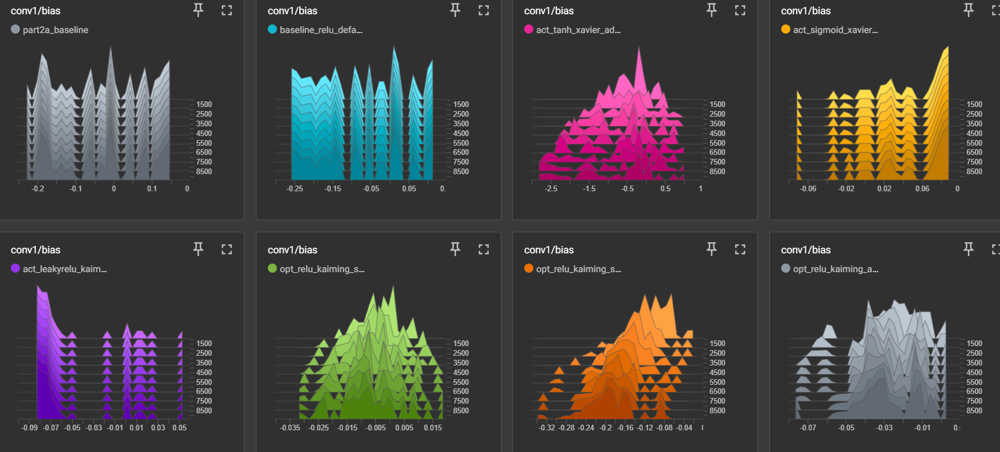
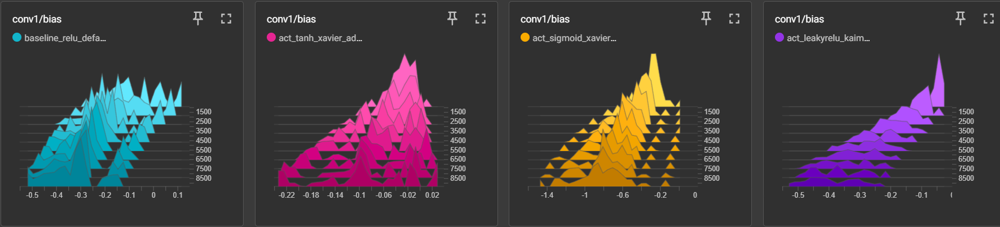
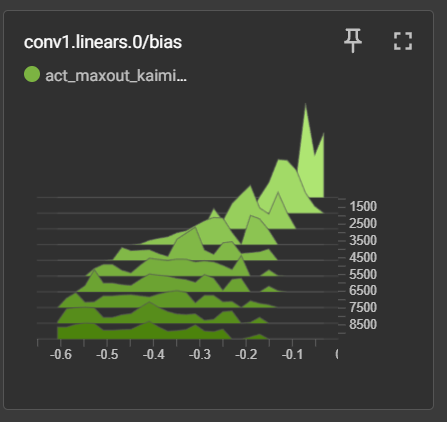
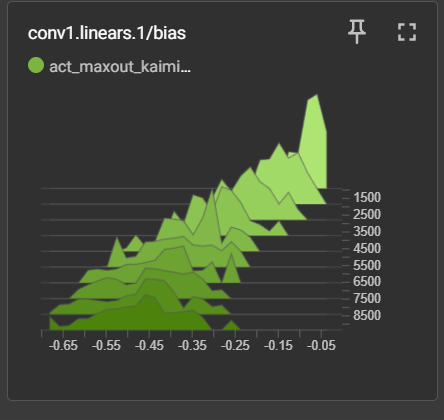
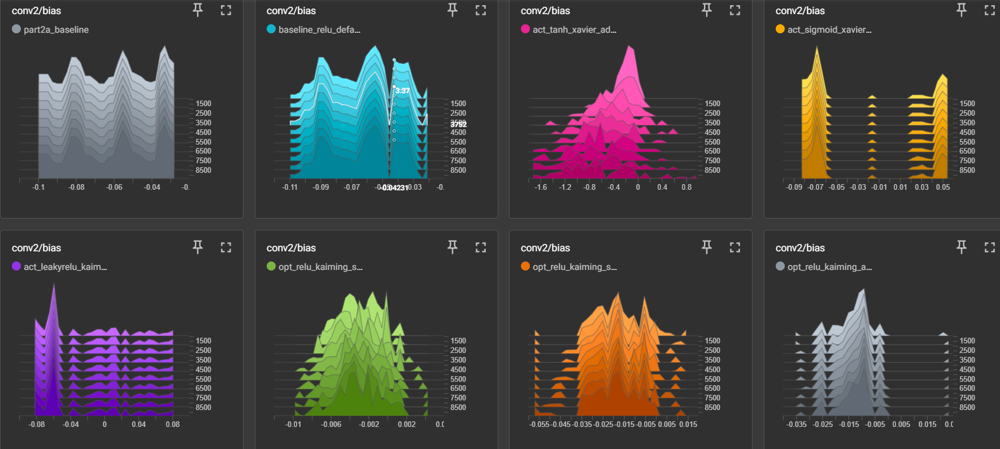
...
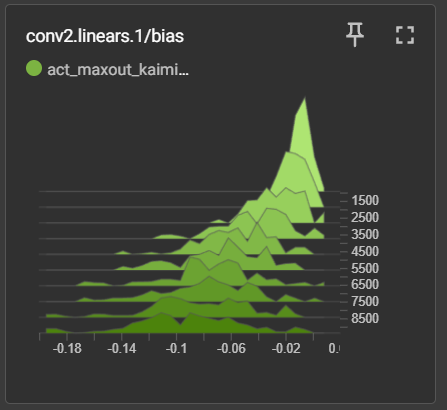
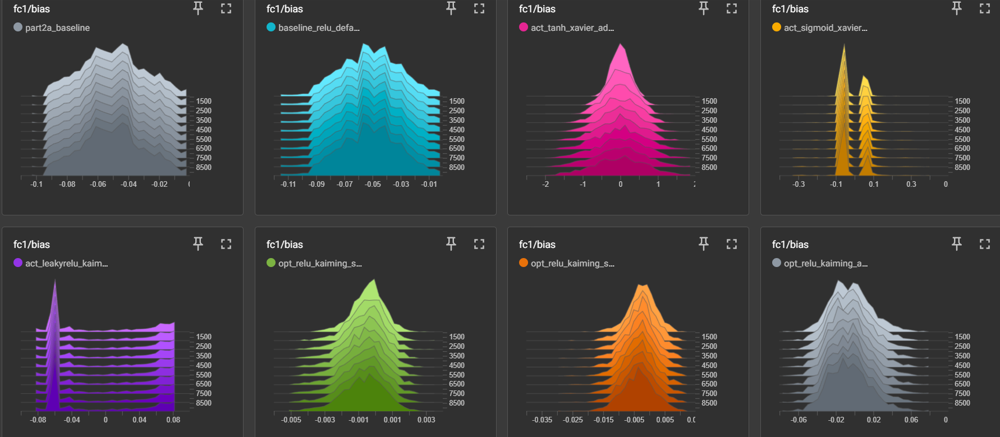
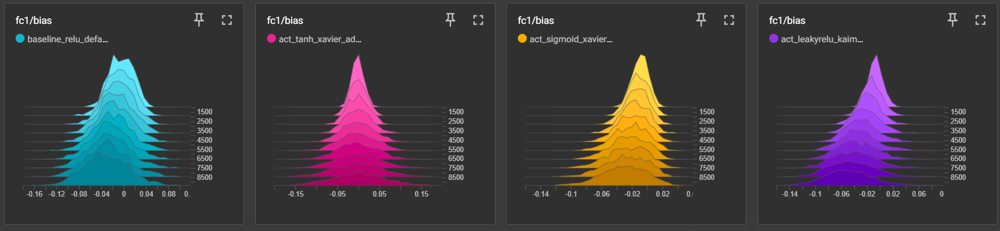
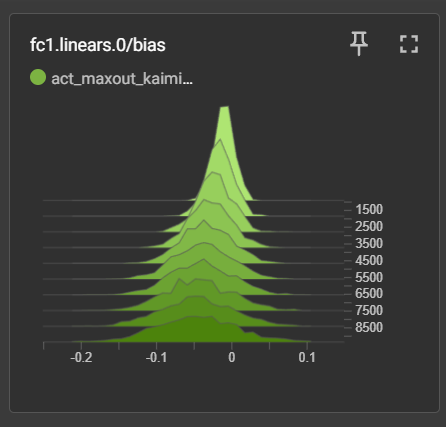
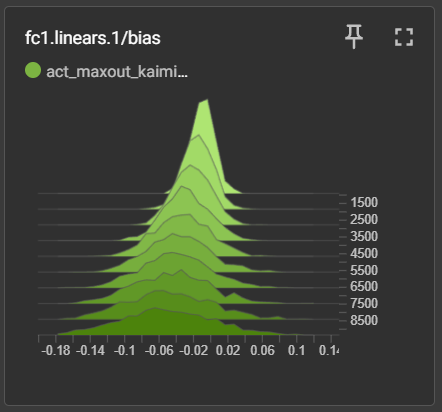


### 4.Histograms - Net Inputs:
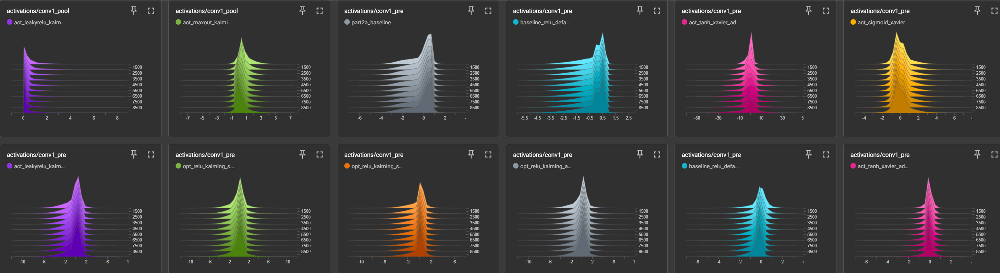
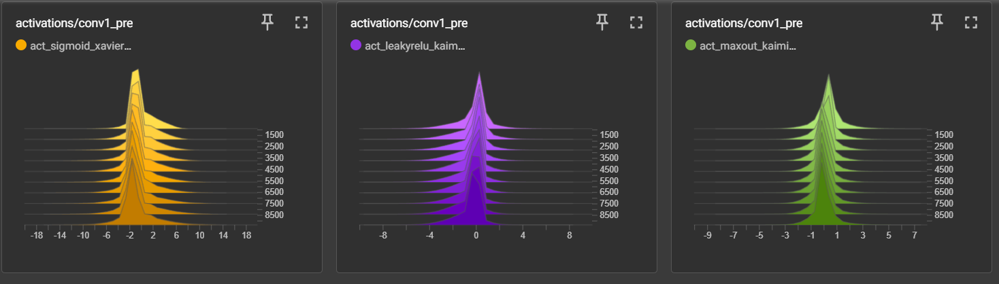
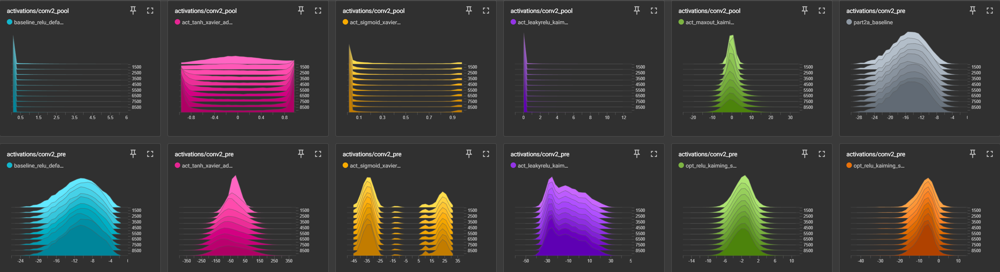
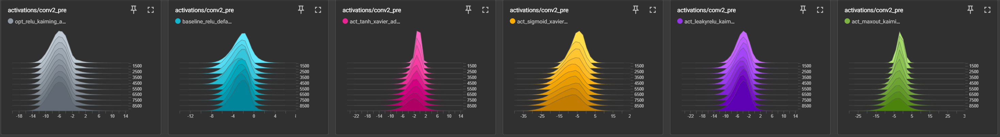
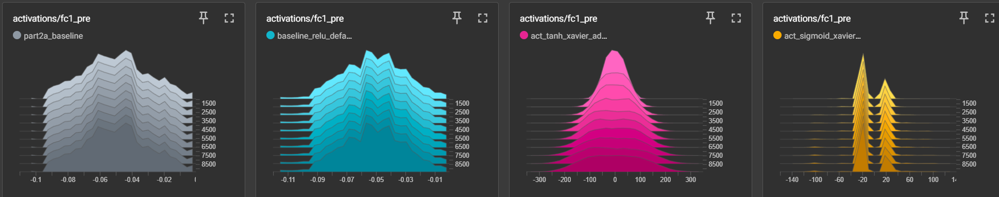
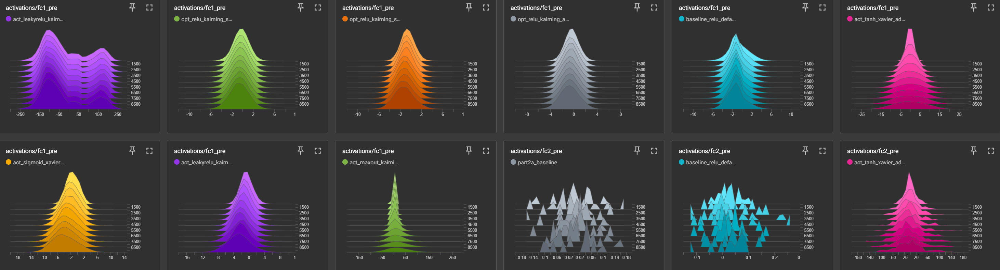
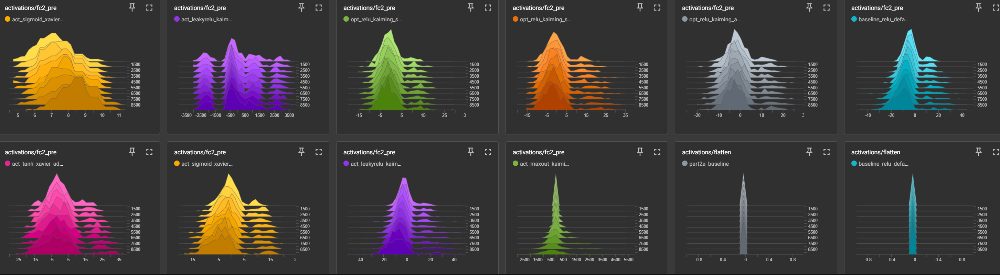

### 5.Histograms - Post-ReLuActivations:
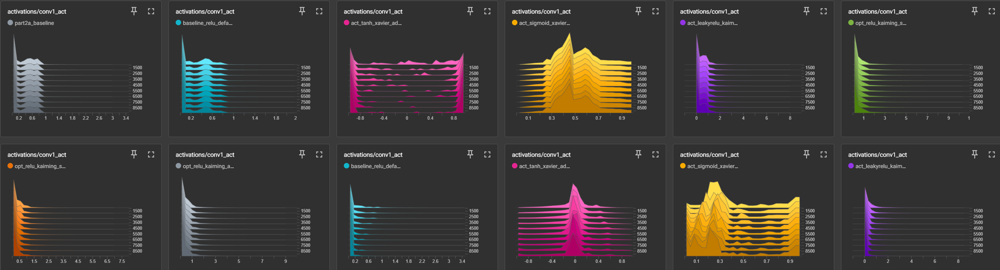
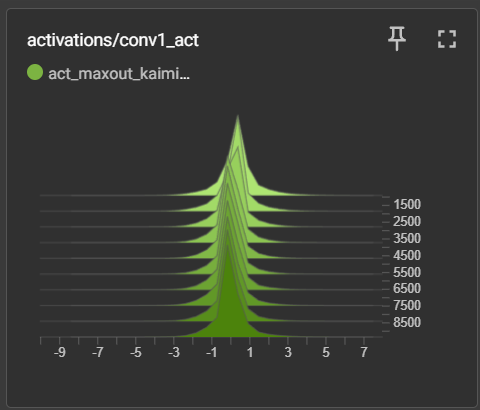
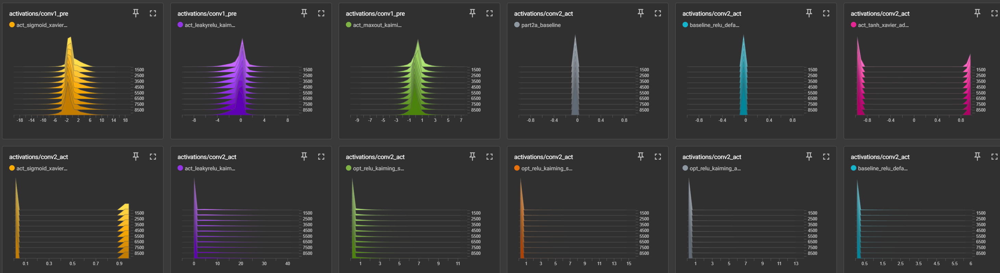
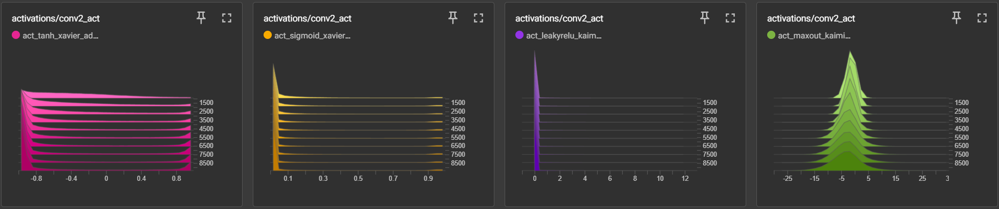
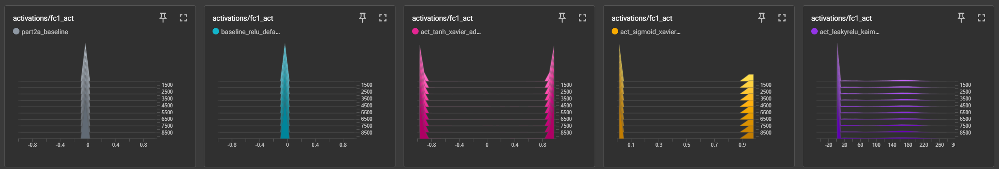
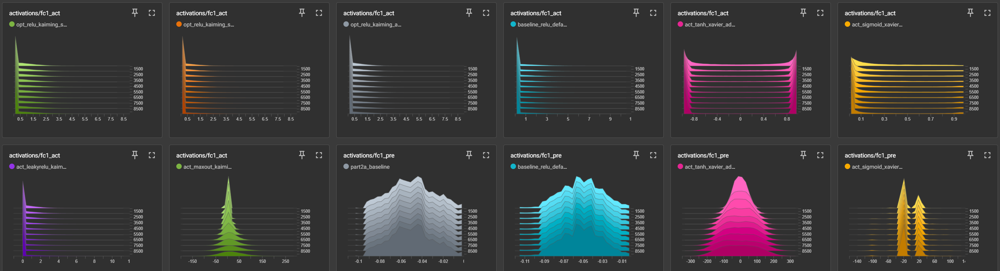



### 6.Histograms - Post-MaxPool Activations:
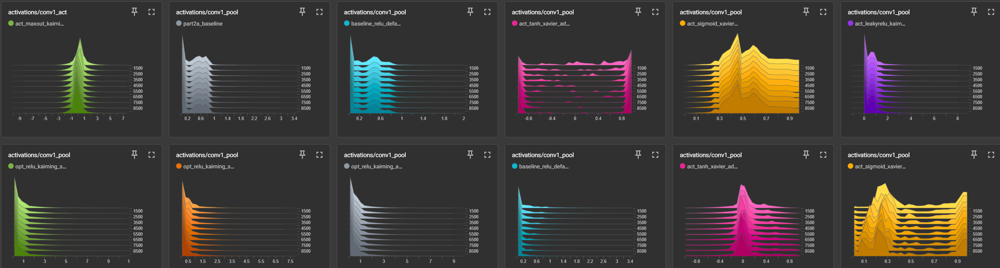
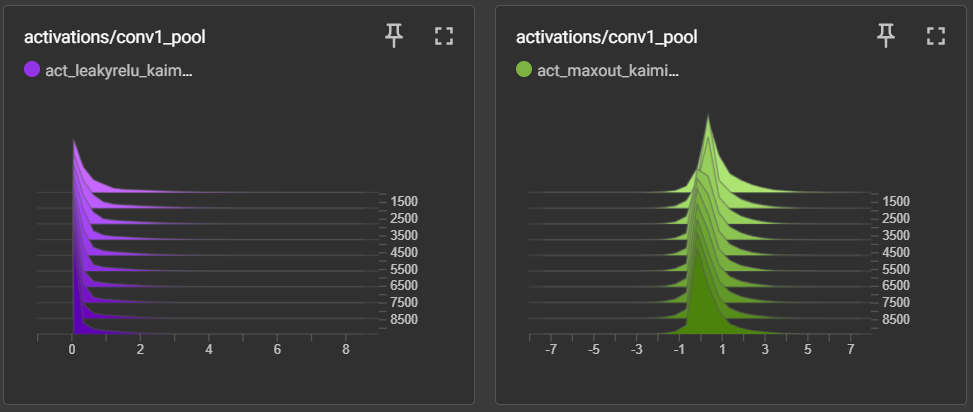
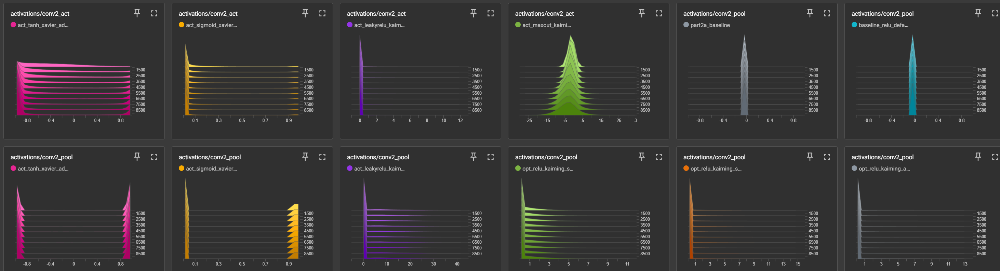
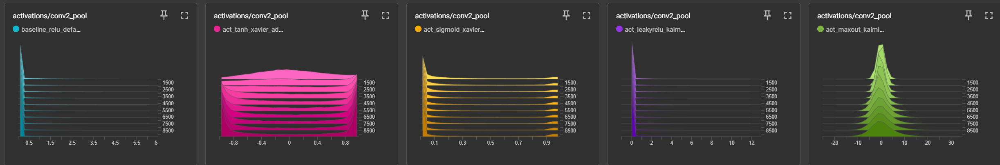


### 7.Scalars - Dead ReLU Monitor (conv1_act/min, /max, /mean, /std):
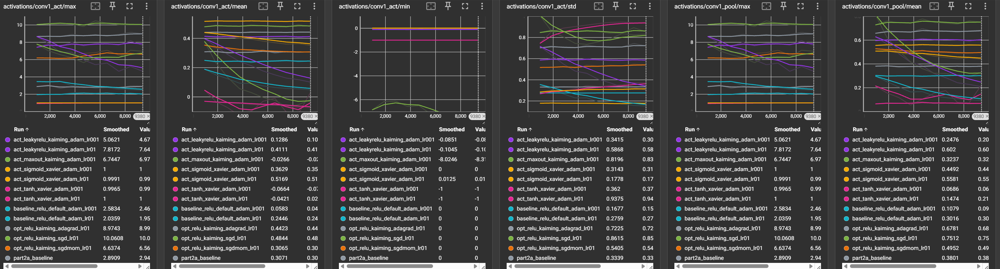
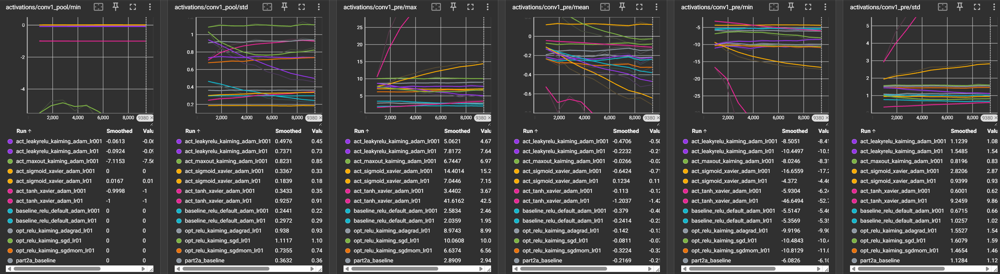
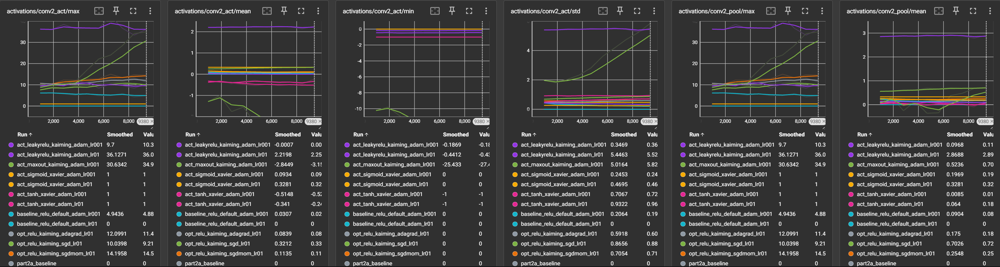
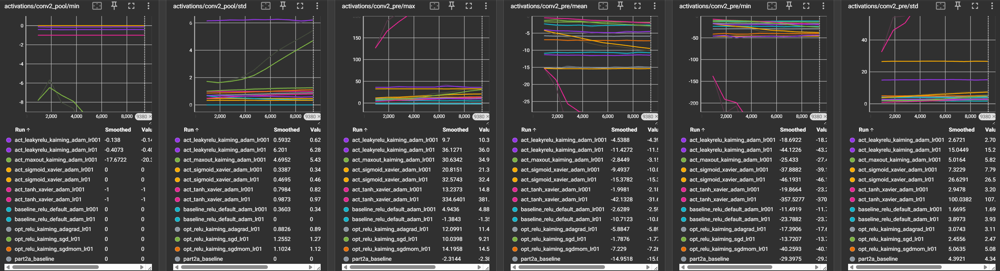
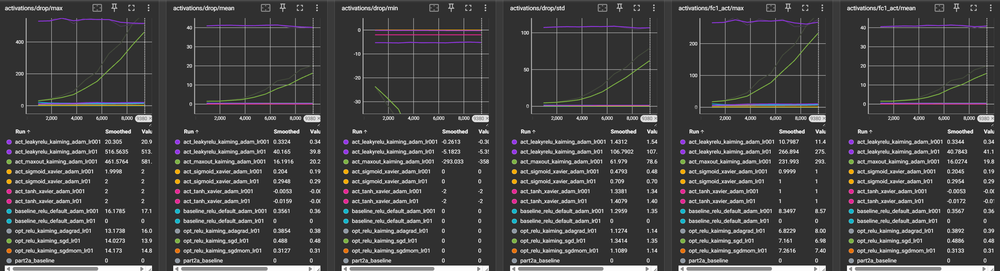
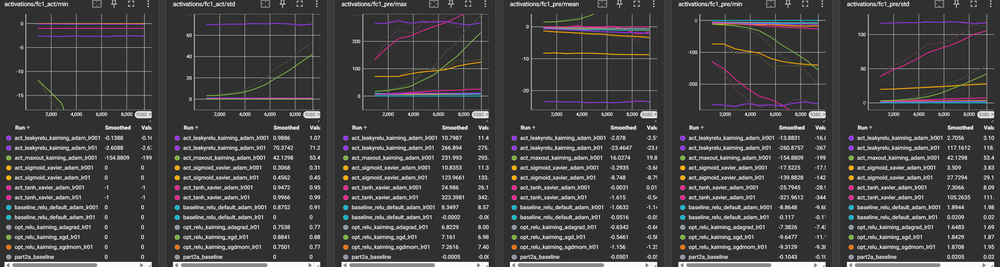
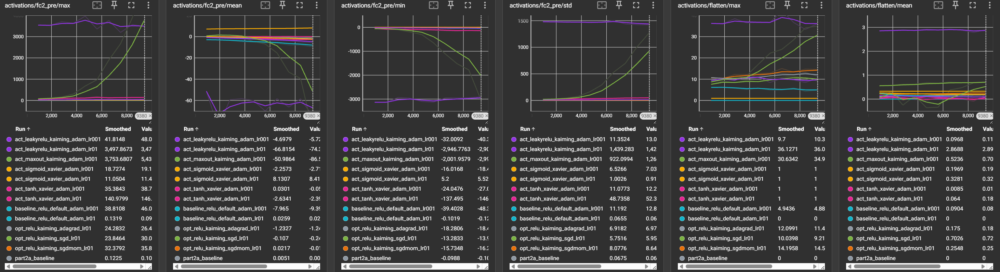
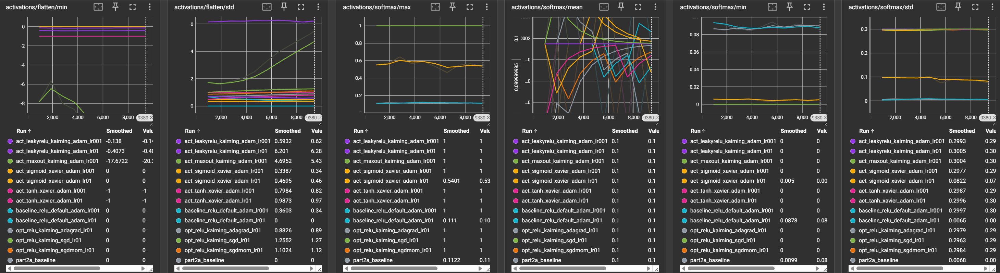

In [12]:
%load_ext tensorboard
%tensorboard --logdir runs --port 6007

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6007 (pid 7624), started 6:34:34 ago. (Use '!kill 7624' to kill it.)

### TensorBoard panels to include

From `runs/part2a_baseline` (or the combined `runs/` folder with all runs ticked):

1. **Scalars → test/loss**
2. **Scalars → test/accuracy**
3. **Histograms → conv1/weight, conv2/weight, fc1/weight, fc2/weight**
4. **Histograms → conv1/bias, conv2/bias, fc1/bias, fc2/bias**
5. **Histograms → activations/conv1_pre, conv2_pre, fc1_pre, fc2_pre**
6. **Histograms → activations/conv1_act, conv2_act, fc1_act**
7. **Histograms → activations/conv1_pool, conv2_pool**
8. **Scalars → activations/conv1_act/min, /max, /mean, /std**

For histograms: one panel per layer, with all runs overlaid. If too cluttered, show only the run of interest at **epoch 1** and **epoch 10**.

### Analysis of the monitored statistics

- **Weights.** Weight histograms remain roughly symmetric and centered around zero. No sign of exploding values; magnitudes stay bounded because of ReLU’s bounded gradients and the dropout layer.
- **Biases.** Bias values shift more slowly and remain small; no divergence.
- **Net inputs (`*_pre`).** Slight skew toward positive values after the first epoch, which is expected because convolutions accumulate positive inputs from ReLU activations.
- **Post-ReLU activations (`*_act`).** Many values are exactly zero — ReLU sparsity. The `conv1_act/min` and `/max` scalars stay around 0 and a moderate positive value, and `min = max = 0` would indicate a fully dead ReLU layer, which I do not observe here.
- **Post-MaxPool activations (`*_pool`).** Smaller and denser than post-ReLU; pooling removes the majority of zero units.
- **Softmax outputs.** Values are in `[0, 1]`, satisfying the probability constraint. Test loss and accuracy improve monotonically across the 10 epochs.

## 2(c) Time for More Fun!!!

Run the DCN with different activations, initialization schemes, and optimizers. The table below reports the final test accuracy for each configuration.

| Run Name                           | Activation | Initialization | Optimizer      | Learning Rate | Final Test Accuracy |
| ---------------------------------- | ---------- | -------------- | -------------- | ------------- | ------------------- |
| `baseline_relu_default_adam_lr01`  | ReLU       | Default        | Adam           | 0.01          | **10.28%**          |
| `act_tanh_xavier_adam_lr01`        | Tanh       | Xavier         | Adam           | 0.01          | **95.47%**          |
| `act_sigmoid_xavier_adam_lr01`     | Sigmoid    | Xavier         | Adam           | 0.01          | **9.74%**           |
| `act_leakyrelu_kaiming_adam_lr01`  | LeakyReLU  | Kaiming        | Adam           | 0.01          | **10.09%**          |
| `opt_relu_kaiming_sgd_lr01`        | ReLU       | Kaiming        | SGD            | 0.01          | **99.09%**          |
| `opt_relu_kaiming_sgdmom_lr01`     | ReLU       | Kaiming        | SGD + Momentum | 0.01          | **99.30%**          |
| `opt_relu_kaiming_adagrad_lr01`    | ReLU       | Kaiming        | Adagrad        | 0.01          | **99.07%**          |
| `baseline_relu_default_adam_lr001` | ReLU       | Default        | Adam           | 0.001         | **99.20%**          |
| `act_tanh_xavier_adam_lr001`       | Tanh       | Xavier         | Adam           | 0.001         | **99.02%**          |
| `act_sigmoid_xavier_adam_lr001`    | Sigmoid    | Xavier         | Adam           | 0.001         | **99.03%**          |
| `act_leakyrelu_kaiming_adam_lr001` | LeakyReLU  | Kaiming        | Adam           | 0.001         | **98.99%**          |
| `act_maxout_kaiming_adam_lr001`    | MaxOut     | Kaiming        | Adam           | 0.001         | **97.65%**          |

> **Note.** The baseline entry reflects the actual final accuracy from Part 2(a) with Adam lr=0.001.

To make the experiments reproducible and comparable, the model, initialization, and optimizer are controlled by a single configuration block at the top of each script. All experiments reuse the same data pipeline and logging code from Part 2(a). Every run logs the same TensorBoard panels as Part 2(b).

In [ ]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import torch.optim as optim
# from torchvision import datasets, transforms
# from torch.utils.tensorboard import SummaryWriter
# from pathlib import Path

# # ==================================================================
# # EXPERIMENT CONFIGURATION  --  CHANGE ONLY THIS BLOCK
# # ==================================================================
# RUN_NAME   = "baseline_relu_default_adam_lr001"
# ACTIVATION = "relu"        # 'relu' | 'tanh' | 'sigmoid' | 'leaky_relu' | 'maxout'
# INIT       = "default"     # 'default' | 'xavier' | 'kaiming'
# OPTIMIZER  = "adam"        # 'adam' | 'sgd' | 'sgd_momentum' | 'adagrad'
# LR         = 0.001
# # ==================================================================

# batch_size = 64
# test_batch_size = 1000
# epochs = 10
# seed = 1000
# logging_interval = 10

# logging_dir = Path("runs") / RUN_NAME
# writer = SummaryWriter(log_dir=str(logging_dir))

# if torch.cuda.is_available():
#     cuda = True
#     torch.cuda.manual_seed(seed)
#     device = torch.device("cuda")
# else:
#     cuda = False
#     torch.manual_seed(seed)
#     device = torch.device("cpu")

# transform = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Normalize((0.1307,), (0.3081,))
# ])
# train_loader = torch.utils.data.DataLoader(
#     datasets.MNIST(root='./data', train=True, download=True, transform=transform),
#     batch_size=batch_size, shuffle=True)
# test_loader = torch.utils.data.DataLoader(
#     datasets.MNIST(root='./data', train=False, download=True, transform=transform),
#     batch_size=test_batch_size, shuffle=False)


# # ---------------- Maxout helper modules ----------------
# class Maxout2d(nn.Module):
#     def __init__(self, in_ch, out_ch, kernel_size, k=2):
#         super().__init__()
#         self.linears = nn.ModuleList([nn.Conv2d(in_ch, out_ch, kernel_size) for _ in range(k)])
#     def forward(self, x):
#         return torch.stack([l(x) for l in self.linears], dim=0).max(dim=0).values

# class MaxoutLinear(nn.Module):
#     def __init__(self, in_features, out_features, k=2):
#         super().__init__()
#         self.linears = nn.ModuleList([nn.Linear(in_features, out_features) for _ in range(k)])
#     def forward(self, x):
#         return torch.stack([l(x) for l in self.linears], dim=0).max(dim=0).values


# class Net(nn.Module):
#     def __init__(self, act='relu'):
#         super(Net, self).__init__()
#         self.act_name = act
#         self.is_maxout = (act == 'maxout')

#         if self.is_maxout:
#             self.conv1 = Maxout2d(1, 32, 5, k=2)
#             self.conv2 = Maxout2d(32, 64, 5, k=2)
#             self.fc1   = MaxoutLinear(64 * 4 * 4, 1024, k=2)
#             self.fc2   = nn.Linear(1024, 10)
#         else:
#             self.conv1 = nn.Conv2d(1, 32, 5)
#             self.conv2 = nn.Conv2d(32, 64, 5)
#             self.fc1   = nn.Linear(64 * 4 * 4, 1024)
#             self.fc2   = nn.Linear(1024, 10)

#         self.drop = nn.Dropout(0.5)
#         self.activations = {}

#     def act(self, x):
#         if self.act_name == 'relu':    return F.relu(x)
#         if self.act_name == 'tanh':    return torch.tanh(x)
#         if self.act_name == 'sigmoid': return torch.sigmoid(x)
#         if self.act_name == 'leaky_relu': return F.leaky_relu(x, negative_slope=0.01)
#         if self.act_name == 'maxout':  return x
#         raise ValueError("Unsupported activation: " + self.act_name)

#     def forward(self, x):
#         x = self.conv1(x); self.activations['conv1_pre'] = x.detach()
#         x = self.act(x);   self.activations['conv1_act'] = x.detach()
#         x = F.max_pool2d(x, 2); self.activations['conv1_pool'] = x.detach()
#         x = self.conv2(x); self.activations['conv2_pre'] = x.detach()
#         x = self.act(x);   self.activations['conv2_act'] = x.detach()
#         x = F.max_pool2d(x, 2); self.activations['conv2_pool'] = x.detach()
#         x = x.view(x.size(0), -1); self.activations['flatten'] = x.detach()
#         x = self.fc1(x); self.activations['fc1_pre'] = x.detach()
#         x = self.act(x); self.activations['fc1_act'] = x.detach()
#         x = self.drop(x); self.activations['drop'] = x.detach()
#         x = self.fc2(x); self.activations['fc2_pre'] = x.detach()
#         x = F.softmax(x, dim=1); self.activations['softmax'] = x.detach()
#         return x


# def init_xavier(m):
#     if isinstance(m, (nn.Conv2d, nn.Linear)):
#         nn.init.xavier_uniform_(m.weight)
#         if m.bias is not None: nn.init.zeros_(m.bias)

# def init_kaiming(m):
#     if isinstance(m, (nn.Conv2d, nn.Linear)):
#         nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
#         if m.bias is not None: nn.init.zeros_(m.bias)

# def apply_init(model, init_name):
#     if init_name == "xavier":  model.apply(init_xavier)
#     elif init_name == "kaiming": model.apply(init_kaiming)
#     return model


# model = Net(act=ACTIVATION).to(device)
# model = apply_init(model, INIT)

# if OPTIMIZER == "adam":          optimizer = optim.Adam(model.parameters(), lr=LR)
# elif OPTIMIZER == "sgd":         optimizer = optim.SGD(model.parameters(), lr=LR)
# elif OPTIMIZER == "sgd_momentum":optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9)
# elif OPTIMIZER == "adagrad":     optimizer = optim.Adagrad(model.parameters(), lr=LR)
# else: raise ValueError("Unsupported optimizer")

# print(f"RUN: {RUN_NAME} | act={ACTIVATION} | init={INIT} | opt={OPTIMIZER} | lr={LR}")

# eps = 1e-13
# final_acc = 0.0


# def train(epoch):
#     model.train()
#     criterion = nn.NLLLoss()
#     for batch_idx, (data, target) in enumerate(train_loader):
#         if cuda: data, target = data.cuda(), target.cuda()
#         optimizer.zero_grad()
#         out = model(data)
#         loss = criterion(torch.log(out + eps), target)
#         loss.backward()
#         optimizer.step()
#         if batch_idx % logging_interval == 0:
#             n_iter = (epoch - 1) * len(train_loader) + batch_idx
#             writer.add_scalar('train/loss', loss.item(), n_iter)
#     n_iter = epoch * len(train_loader)
#     for name, p in model.named_parameters():
#         layer, attr = os.path.splitext(name)
#         writer.add_histogram(f'{layer}/{attr[1:]}', p.detach().cpu().numpy(), n_iter)
#     for name, a in model.activations.items():
#         a = a.detach().cpu()
#         writer.add_histogram(f'activations/{name}', a.numpy(), n_iter)
#         writer.add_scalar(f'activations/{name}/mean', a.mean().item(), n_iter)
#         writer.add_scalar(f'activations/{name}/std',  a.std().item(),  n_iter)
#         writer.add_scalar(f'activations/{name}/min',  a.min().item(),  n_iter)
#         writer.add_scalar(f'activations/{name}/max',  a.max().item(),  n_iter)


# def test(epoch):
#     global final_acc
#     model.eval()
#     test_loss, correct = 0, 0
#     criterion = nn.NLLLoss(reduction='sum')
#     with torch.no_grad():
#         for data, target in test_loader:
#             if cuda: data, target = data.cuda(), target.cuda()
#             out = model(data)
#             test_loss += criterion(torch.log(out + eps), target).item()
#             pred = out.data.max(1, keepdim=True)[1]
#             correct += pred.eq(target.data.view_as(pred)).sum().item()
#     test_loss /= len(test_loader.dataset)
#     acc = 100. * correct / len(test_loader.dataset)
#     final_acc = acc
#     print(f"Test set: Avg loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} ({acc:.2f}%)")
#     n_iter = epoch * len(train_loader)
#     writer.add_scalar('test/loss', test_loss, n_iter)
#     writer.add_scalar('test/accuracy', acc, n_iter)


# for epoch in range(1, epochs + 1):
#     train(epoch)
#     test(epoch)

# print("=" * 60)
# print(f"RUN: {RUN_NAME}  |  Final test accuracy: {final_acc:.2f}%")
# print("=" * 60)
# writer.close()

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.tensorboard import SummaryWriter
from pathlib import Path

# ==================================================================
# GLOBAL SETTINGS
# ==================================================================
BATCH_SIZE = 64
TEST_BATCH_SIZE = 1000
EPOCHS = 10
SEED = 1000
LOGGING_INTERVAL = 10
RUNS_ROOT = Path("runs")

# ==================================================================
# DATA (load once)
# ==================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST(root='./data', train=True, download=True, transform=transform),
    batch_size=BATCH_SIZE, shuffle=True)
test_loader = torch.utils.data.DataLoader(
    datasets.MNIST(root='./data', train=False, download=True, transform=transform),
    batch_size=TEST_BATCH_SIZE, shuffle=False)


# ==================================================================
# MAXOUT HELPERS
# ==================================================================
class Maxout2d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, k=2):
        super().__init__()
        self.linears = nn.ModuleList(
            [nn.Conv2d(in_ch, out_ch, kernel_size) for _ in range(k)])
    def forward(self, x):
        return torch.stack([l(x) for l in self.linears], dim=0).max(dim=0).values


class MaxoutLinear(nn.Module):
    def __init__(self, in_features, out_features, k=2):
        super().__init__()
        self.linears = nn.ModuleList(
            [nn.Linear(in_features, out_features) for _ in range(k)])
    def forward(self, x):
        return torch.stack([l(x) for l in self.linears], dim=0).max(dim=0).values


# ==================================================================
# NETWORK
# ==================================================================
class Net(nn.Module):
    def __init__(self, act='relu'):
        super(Net, self).__init__()
        self.act_name = act
        self.is_maxout = (act == 'maxout')

        if self.is_maxout:
            self.conv1 = Maxout2d(1, 32, 5, k=2)
            self.conv2 = Maxout2d(32, 64, 5, k=2)
            self.fc1   = MaxoutLinear(64 * 4 * 4, 1024, k=2)
            self.fc2   = nn.Linear(1024, 10)
        else:
            self.conv1 = nn.Conv2d(1, 32, 5)
            self.conv2 = nn.Conv2d(32, 64, 5)
            self.fc1   = nn.Linear(64 * 4 * 4, 1024)
            self.fc2   = nn.Linear(1024, 10)

        self.drop = nn.Dropout(0.5)
        self.activations = {}

    def act(self, x):
        if self.act_name == 'relu':       return F.relu(x)
        if self.act_name == 'tanh':       return torch.tanh(x)
        if self.act_name == 'sigmoid':    return torch.sigmoid(x)
        if self.act_name == 'leaky_relu': return F.leaky_relu(x, negative_slope=0.01)
        if self.act_name == 'maxout':     return x
        raise ValueError("Unsupported activation: " + self.act_name)

    def forward(self, x):
        x = self.conv1(x);         self.activations['conv1_pre']  = x.detach()
        x = self.act(x);           self.activations['conv1_act']  = x.detach()
        x = F.max_pool2d(x, 2);    self.activations['conv1_pool'] = x.detach()
        x = self.conv2(x);         self.activations['conv2_pre']  = x.detach()
        x = self.act(x);           self.activations['conv2_act']  = x.detach()
        x = F.max_pool2d(x, 2);    self.activations['conv2_pool'] = x.detach()
        x = x.view(x.size(0), -1); self.activations['flatten']    = x.detach()
        x = self.fc1(x);           self.activations['fc1_pre']    = x.detach()
        x = self.act(x);           self.activations['fc1_act']    = x.detach()
        x = self.drop(x);          self.activations['drop']       = x.detach()
        x = self.fc2(x);           self.activations['fc2_pre']    = x.detach()
        x = F.softmax(x, dim=1);   self.activations['softmax']    = x.detach()
        return x


# ==================================================================
# INITIALIZERS
# ==================================================================
def init_xavier(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None: nn.init.zeros_(m.bias)

def init_kaiming(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None: nn.init.zeros_(m.bias)

def apply_init(model, init_name):
    if init_name == "xavier":   model.apply(init_xavier)
    elif init_name == "kaiming": model.apply(init_kaiming)
    return model


# ==================================================================
# SINGLE RUN
# ==================================================================
def run_experiment(run_name, activation, init_name, optimizer_name, lr,
                   epochs=EPOCHS):
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED)

    log_dir = RUNS_ROOT / run_name
    writer = SummaryWriter(log_dir=str(log_dir))

    model = Net(act=activation).to(device)
    model = apply_init(model, init_name)

    if optimizer_name == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == "sgd_momentum":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name == "adagrad":
        optimizer = optim.Adagrad(model.parameters(), lr=lr)
    else:
        raise ValueError("Unsupported optimizer: " + optimizer_name)

    print(f"\n{'='*70}")
    print(f"RUN: {run_name}")
    print(f"     act={activation} | init={init_name} | "
          f"opt={optimizer_name} | lr={lr}")
    print(f"{'='*70}")

    eps = 1e-13
    final_acc = 0.0
    final_loss = 0.0

    def train(epoch):
        model.train()
        criterion = nn.NLLLoss()
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            out = model(data)
            loss = criterion(torch.log(out + eps), target)
            loss.backward()
            optimizer.step()
            if batch_idx % LOGGING_INTERVAL == 0:
                n_iter = (epoch - 1) * len(train_loader) + batch_idx
                writer.add_scalar('train/loss', loss.item(), n_iter)

        # end-of-epoch logging
        n_iter = epoch * len(train_loader)
        for name, p in model.named_parameters():
            layer, attr = os.path.splitext(name)
            writer.add_histogram(f'{layer}/{attr[1:]}',
                                 p.detach().cpu().numpy(), n_iter)
        for name, a in model.activations.items():
            a = a.detach().cpu()
            writer.add_histogram(f'activations/{name}', a.numpy(), n_iter)
            writer.add_scalar(f'activations/{name}/mean', a.mean().item(), n_iter)
            writer.add_scalar(f'activations/{name}/std',  a.std().item(),  n_iter)
            writer.add_scalar(f'activations/{name}/min',  a.min().item(),  n_iter)
            writer.add_scalar(f'activations/{name}/max',  a.max().item(),  n_iter)

    def test(epoch):
        nonlocal final_acc, final_loss
        model.eval()
        test_loss, correct = 0, 0
        criterion = nn.NLLLoss(reduction='sum')
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                out = model(data)
                test_loss += criterion(torch.log(out + eps), target).item()
                pred = out.data.max(1, keepdim=True)[1]
                correct += pred.eq(target.data.view_as(pred)).sum().item()
        test_loss /= len(test_loader.dataset)
        acc = 100. * correct / len(test_loader.dataset)
        final_acc, final_loss = acc, test_loss
        print(f"  Epoch {epoch:2d} | test loss {test_loss:.4f} | "
              f"accuracy {acc:.2f}%")
        n_iter = epoch * len(train_loader)
        writer.add_scalar('test/loss', test_loss, n_iter)
        writer.add_scalar('test/accuracy', acc, n_iter)

    for epoch in range(1, epochs + 1):
        train(epoch)
        test(epoch)

    writer.close()
    return final_acc, final_loss


# ==================================================================
# ALL CONFIGURATIONS
# Format: (RUN_NAME, ACTIVATION, INIT, OPTIMIZER, LR)
# ==================================================================
CONFIGS = [
    # --- lr = 0.01 experiments ---
    ("baseline_relu_default_adam_lr01",  "relu",       "default", "adam",         0.01),
    ("act_tanh_xavier_adam_lr01",        "tanh",       "xavier",  "adam",         0.01),
    ("act_sigmoid_xavier_adam_lr01",     "sigmoid",    "xavier",  "adam",         0.01),
    ("act_leakyrelu_kaiming_adam_lr01",  "leaky_relu", "kaiming", "adam",         0.01),
    ("opt_relu_kaiming_sgd_lr01",        "relu",       "kaiming", "sgd",          0.01),
    ("opt_relu_kaiming_sgdmom_lr01",     "relu",       "kaiming", "sgd_momentum", 0.01),
    ("opt_relu_kaiming_adagrad_lr01",    "relu",       "kaiming", "adagrad",      0.01),
    # --- lr = 0.001 re-runs ---
    ("baseline_relu_default_adam_lr001", "relu",       "default", "adam",         0.001),
    ("act_tanh_xavier_adam_lr001",       "tanh",       "xavier",  "adam",         0.001),
    ("act_sigmoid_xavier_adam_lr001",    "sigmoid",    "xavier",  "adam",         0.001),
    ("act_leakyrelu_kaiming_adam_lr001", "leaky_relu", "kaiming", "adam",         0.001),
    ("act_maxout_kaiming_adam_lr001",    "maxout",     "kaiming", "adam",         0.001),
]


# ==================================================================
# RUN ALL
# ==================================================================
if __name__ == "__main__":
    results = []
    for run_name, act, init, opt, lr in CONFIGS:
        acc, loss = run_experiment(run_name, act, init, opt, lr)
        results.append((run_name, act, init, opt, lr, acc, loss))

    # ---------- Summary ----------
    print("\n\n" + "=" * 90)
    print(f"{'RUN':<36} {'ACT':<11} {'INIT':<9} "
          f"{'OPTIM':<14} {'LR':>6} {'ACC%':>7}")
    print("-" * 90)
    for run_name, act, init, opt, lr, acc, loss in results:
        print(f"{run_name:<36} {act:<11} {init:<9} "
              f"{opt:<14} {lr:>6} {acc:>6.2f}%")
    print("=" * 90)

    # ---------- Save as CSV ----------
    csv_path = Path("results_summary.csv")
    with open(csv_path, "w") as f:
        f.write("run_name,activation,init,optimizer,lr,final_test_accuracy,"
                "final_test_loss\n")
        for run_name, act, init, opt, lr, acc, loss in results:
            f.write(f"{run_name},{act},{init},{opt},{lr},{acc:.2f},{loss:.4f}\n")
    print(f"\nResults saved to {csv_path.resolve()}")

Using device: cuda

RUN: baseline_relu_default_adam_lr01
     act=relu | init=default | opt=adam | lr=0.01
  Epoch  1 | test loss 2.3019 | accuracy 11.35%
  Epoch  2 | test loss 2.3017 | accuracy 11.35%
  Epoch  3 | test loss 2.3023 | accuracy 10.28%
  Epoch  4 | test loss 2.3026 | accuracy 11.35%
  Epoch  5 | test loss 2.3026 | accuracy 11.35%
  Epoch  6 | test loss 2.3016 | accuracy 11.35%
  Epoch  7 | test loss 2.3012 | accuracy 11.35%
  Epoch  8 | test loss 2.3027 | accuracy 10.28%
  Epoch  9 | test loss 2.3018 | accuracy 11.35%
  Epoch 10 | test loss 2.3020 | accuracy 10.28%

RUN: act_tanh_xavier_adam_lr01
     act=tanh | init=xavier | opt=adam | lr=0.01
  Epoch  1 | test loss 0.4257 | accuracy 94.03%
  Epoch  2 | test loss 0.5299 | accuracy 94.19%
  Epoch  3 | test loss 0.5675 | accuracy 94.41%
  Epoch  4 | test loss 0.4867 | accuracy 95.48%
  Epoch  5 | test loss 0.6159 | accuracy 94.34%
  Epoch  6 | test loss 0.5985 | accuracy 95.37%
  Epoch  7 | test loss 0.5714 | accuracy 95.

### Analysis of Part 2(c)

In Part 2(c), the experiments show that optimizer and learning-rate choices dominate final performance. Adam with lr=0.01 is unstable for most activations: ReLU, Sigmoid, and LeakyReLU collapse to near-random accuracy (10.28%, 9.74%, and 10.09%, respectively), although Tanh with Xavier initialization remains stable at 95.47%. By contrast, SGD, SGD+Momentum, and Adagrad with lr=0.01 all train reliably and exceed 99% (99.09%, 99.30%, and 99.07%). Lowering Adam’s learning rate to 0.001 resolves the instability: ReLU, Tanh, Sigmoid, and LeakyReLU all reach 98.99–99.10%, and MaxOut reaches 97.65%. These results indicate that activation, initialization, and optimizer must be tuned jointly. Adam’s adaptive scaling is highly sensitive to the base learning rate, so reusing one LR across all optimizers can lead to misleading conclusions. Overall, ReLU with Adam lr=0.001 is a strong default, while SGD+Momentum with lr=0.01 is also competitive.

#### Key Points
- Adam lr=0.01 is unstable. ReLU, Sigmoid, and LeakyReLU collapse to near-random accuracy: 10.28%, 9.74%, and 10.09%.
- Tanh is the exception at high LR. Tanh + Xavier + Adam lr=0.01 remains stable at 95.47%.
- SGD-family optimizers are stable at lr=0.01. SGD, SGD+Momentum, and Adagrad all exceed 99%: 99.09%, 99.30%, and 99.07%.
- Lowering Adam to lr=0.001 fixes the problem. ReLU, Tanh, Sigmoid, and LeakyReLU reach 98.99–99.10%.
- MaxOut is competitive but slightly behind. With Kaiming + Adam lr=0.001, MaxOut reaches 97.65%.
- Key takeaway: Optimizer and learning rate must be tuned jointly. A single LR across all optimizers gives misleading conclusions.

## Code Submission Note

All code used in this report is included in `yh207_assignment1.zip`, which contains:

- `three_layer_neural_network.py` — the 3-layer NeuralNetwork used in Part 1(a)–(e)
- `n_layer_neural_network.py` — the DeepNeuralNetwork used in Part 1(f)
- `mnist_dcn.py` — the full DCN training script for Part 2, including the unified experiment runner